# ATIS Intent Classification — TF-IDF LR · TextCNN · CharCNN

Three models, no `sklearn` for any model weights:

| # | Features | Model |
|---|----------|-------|
| 1 | TF-IDF (sklearn vectoriser → dense tensor) | Logistic Regression in PyTorch (`nn.Linear` + cross-entropy) |
| 2 | Word token IDs → learned embeddings | TextCNN — parallel conv filters of width 2/3/4 (Kim 2014) |
| 3 | Character IDs | CharCNN — stacked 1-D convolutions |

**Roadmap**

0. Setup (imports, seeds, device)
1. Data loading
1.5. Data exploration — stop words (corpus), class imbalance, test-only intents, ambiguity, domain vocabulary, semantic similarity
2. Train/validation split (+ optional §1.6 random deletion on train)
3. Model 1 — TF-IDF → PyTorch LR
4. Model 2 — TextCNN
5. Model 3 — CharCNN
6. Comparison & diagnostics
7. Interactive inference

In [42]:
import json
import random
import re
import time
import zipfile
from collections.abc import Callable
from pathlib import Path
from types import SimpleNamespace
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sentencepiece as spm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset

_GLOVE_ZIP_URL = {
    "42B": "http://nlp.stanford.edu/data/glove.42B.300d.zip",
    "840B": "http://nlp.stanford.edu/data/glove.840B.300d.zip",
    "twitter.27B": "http://nlp.stanford.edu/data/glove.twitter.27B.zip",
    "6B": "http://nlp.stanford.edu/data/glove.6B.zip",
}


def load_glove_vectors(
    name: str = "6B",
    dim: int = 100,
    cache: Path | None = None,
) -> SimpleNamespace:
    """Stanford GloVe (same archives as torchtext); avoids the torchtext C++ extension."""
    if name not in _GLOVE_ZIP_URL:
        raise ValueError(f"Unknown GloVe bundle {name!r}; choose from {list(_GLOVE_ZIP_URL)}")
    cache = Path(cache or Path(".vector_cache").resolve())
    cache.mkdir(parents=True, exist_ok=True)
    txt_name = f"glove.{name}.{dim}d.txt"
    path_txt = cache / txt_name
    path_pt = cache / f"{txt_name}.pt"
    if path_pt.is_file():
        _itos, stoi, vectors, _d = torch.load(path_pt, map_location="cpu", weights_only=False)
        return SimpleNamespace(stoi=stoi, vectors=vectors)
    if not path_txt.is_file():
        url = _GLOVE_ZIP_URL[name]
        zip_name = url.rsplit("/", 1)[-1]
        dest_zip = cache / zip_name
        if not dest_zip.is_file():
            print(f"Downloading {zip_name} (first run only) ...")
            urlretrieve(url, dest_zip)
        with zipfile.ZipFile(dest_zip, "r") as zf:
            zf.extractall(cache)
    if not path_txt.is_file():
        raise FileNotFoundError(
            f"Expected {path_txt} in the archive; check name/dim "
            "(e.g. glove.6B with dim 50, 100, 200, or 300)."
        )
    itos: list[str] = []
    rows: list[list[float]] = []
    with open(path_txt, encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.rstrip().split()
            if len(parts) != dim + 1:
                continue
            itos.append(parts[0])
            rows.append([float(x) for x in parts[1:]])
    vectors = torch.tensor(rows, dtype=torch.float32)
    stoi = {w: i for i, w in enumerate(itos)}
    torch.save((itos, stoi, vectors, dim), path_pt)
    return SimpleNamespace(stoi=stoi, vectors=vectors)


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.preprocessing import LabelEncoder

# ── reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── paths ─────────────────────────────────────────────────────────────────────
ROOT = Path(r"C:\Users\user\Documents\Python Scripts\atis_intent_classification")
DATA_DIR = ROOT / "data"
TRAIN_JSON = DATA_DIR / "train.json"
TEST_JSON = DATA_DIR / "test.json"

# ── hyper-parameters (shared) ────────────────────────────────────────────────
BATCH_SIZE = 64
MAX_EPOCHS = 40
PATIENCE = 10
LR = 3e-3
EMBED_DIM = 128

Device: cuda


## 1 — Data loading

[data] INTENT_FILTER_SHARED_ONLY=False — full splits
Train samples : 4,978  |  intents (this split): 22
Test  samples : 893  |  intents in test but not train: ['airfare+flight', 'day_name', 'flight+airline', 'flight_no+airline']
Total classes : 26


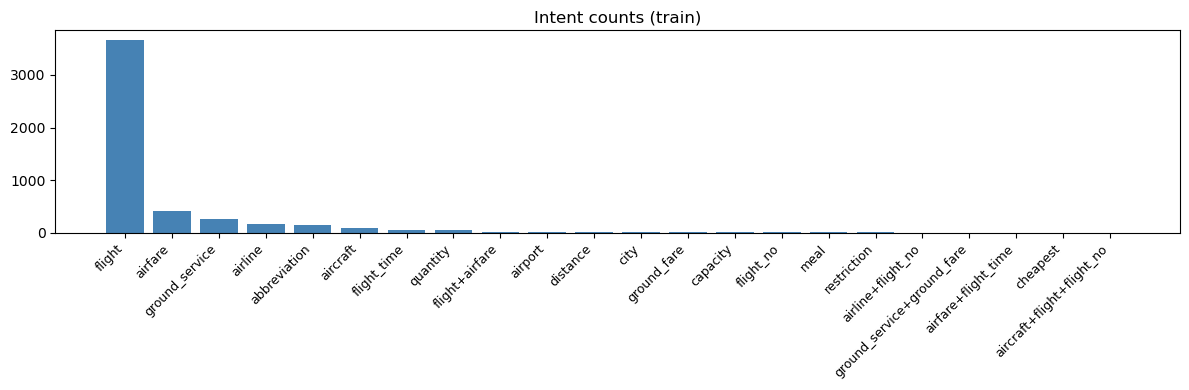

In [43]:
def load_rasa_json(path: Path) -> pd.DataFrame:
    data = json.loads(path.read_text(encoding="utf-8"))
    rows = []
    for ex in data["rasa_nlu_data"]["common_examples"]:
        rows.append({"text": ex["text"].strip(), "intent": ex["intent"].strip()})
    return pd.DataFrame(rows)


train_df = load_rasa_json(TRAIN_JSON)
test_df = load_rasa_json(TEST_JSON)

# When True: drop rows whose intent appears only in train or only in test
# (closed label set = intersection of intent names). Default ON for a fair
# supervised benchmark; set False to recover the full ATIS label space.
INTENT_FILTER_SHARED_ONLY = False

_n_tr0, _n_te0 = len(train_df), len(test_df)
_tr_int0 = set(train_df["intent"])
_te_int0 = set(test_df["intent"])
_asym_tr = sorted(_tr_int0 - _te_int0)
_asym_te = sorted(_te_int0 - _tr_int0)

if INTENT_FILTER_SHARED_ONLY:
    shared = _tr_int0 & _te_int0
    train_df = train_df[train_df["intent"].isin(shared)].reset_index(drop=True)
    test_df = test_df[test_df["intent"].isin(shared)].reset_index(drop=True)
    print("[data] INTENT_FILTER_SHARED_ONLY=True — keeping train∩test intents only")
    print(
        f"       asymmetric before filter — train-only: {len(_asym_tr)}, test-only: {len(_asym_te)}"
    )
    print(
        f"       dropped rows — train: {_n_tr0 - len(train_df):,}, test: {_n_te0 - len(test_df):,}"
    )
else:
    print("[data] INTENT_FILTER_SHARED_ONLY=False — full splits")

# Sorted unique intents → reproducible LabelEncoder IDs
label_encoder = LabelEncoder()
_intents_sorted = np.sort(pd.unique(pd.concat([train_df["intent"], test_df["intent"]])))
label_encoder.fit(_intents_sorted)
NUM_CLASSES = len(label_encoder.classes_)

train_df["label"] = label_encoder.transform(train_df["intent"])
test_df["label"] = label_encoder.transform(test_df["intent"])

_tr_int = set(train_df["intent"])
_te_int = set(test_df["intent"])
print(f"Train samples : {len(train_df):,}  |  intents (this split): {len(_tr_int)}")
print(
    f"Test  samples : {len(test_df):,}  |  intents in test but not train: {sorted(_te_int - _tr_int)}"
)
print(f"Total classes : {NUM_CLASSES}")

# ── quick intent distribution ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
top = train_df["intent"].value_counts()
ax.bar(top.index, top.values, color="steelblue")
ax.set_xticks(np.arange(len(top)), labels=top.index, rotation=45, ha="right", fontsize=9)
ax.set_title("Intent counts (train)")
plt.tight_layout()
plt.show()

## 1.5 — Data Exploration

Several properties of ATIS shape the modelling choices that come next:

1. **Stop words (corpus)** — descriptive share of **`sklearn.feature_extraction.text.ENGLISH_STOP_WORDS`** under a simple alphanumeric tokenizer (§1.5.1). Travel phrasing relies on tokens that overlap standard stop lists (`from`, `to`, …), so blindly removing stops in downstream models would be questionable; explore only.
2. **Class imbalance** — some intents (esp. `flight`) dominate the training set. A naive model can get decent accuracy by always predicting the majority class. We need to monitor **per-class** performance, not just overall accuracy.
3. **Train/test intent overlap** — ATIS has intents that appear only in train or only in test. By default (**`INTENT_FILTER_SHARED_ONLY=True`** in §1 data loading) we drop those rows and benchmark on the **closed** intent set (`train ∩ test`). Set the flag to `False` if you want the full label space instead; §1.5.3 then surfaces test-only intents and the accuracy ceiling they impose.
4. **Intent Ambiguity** — queries like *"what's the price of a flight to boston"* overlap `flight` and `airfare`. Some errors aren't model failure, they're genuine label ambiguity.
5. **Domain Vocabulary** — ATIS mixes everyday English with airport codes (`dfw`, `jfk`), airline names, and city names. How the tokenizer treats these affects OOV rates and generalisation (see §1.5.5 for collapse/mask tooling).
6. **Semantic similarity** — intent names like `flight`, `flight_time`, `flight_no` are close siblings. Distinguishing them needs attention to specific keywords (e.g., `"what time"`, `"flight number"`), not just general topic.

### 1.5.1 — Stop words (corpus)

We summarise how much of the raw corpus is made up of **`sklearn.feature_extraction.text.ENGLISH_STOP_WORDS`** (frozen set bundled with sklearn). Tokens are **[a-z0-9]+** runs on lowercased text—a lightweight exploratory tokenizer that **does not** apply multi-word collapse or **`MASK_ENTITIES`** masking used in §1.5.5.

Many high-frequency stops (*from*, *to*, *i*, *the*, …) are still **semantically load-bearing** on ATIS routing queries, so treating this subsection as exploratory only—not a rationale for automatic stop-word removal—is intentional.

[train] total_tokens=56,690   stop_tokens=27,296 (48.15%)   vocab(unique)=886   distinct_sklearn_stops_seen=143   |sklearn.lexicon|=318
[test ] total_tokens=9,200   stop_tokens=4,006 (43.54%)   vocab(unique)=448   distinct_sklearn_stops_seen=89   |sklearn.lexicon|=318


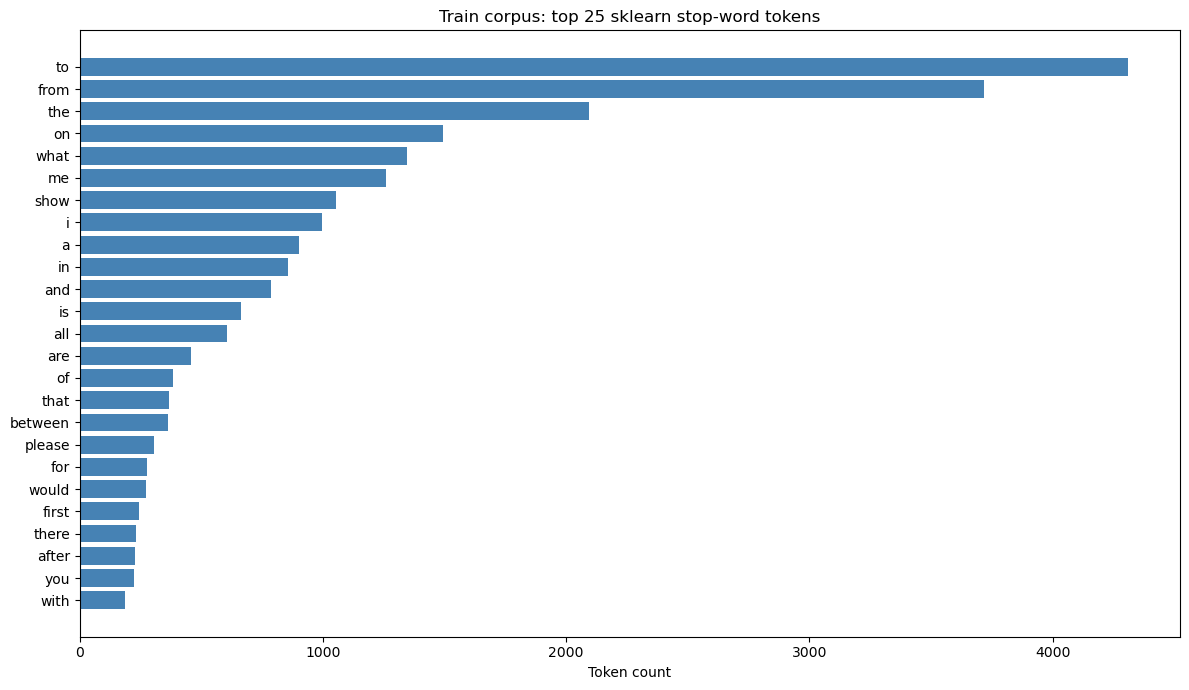

In [44]:
from collections import Counter

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as _ENG_STOPS

_EXPLORE_WORD_RE = re.compile(r"[a-z0-9]+")
_ENG_STOP_FROZEN = frozenset(_ENG_STOPS)


def explore_corpus_tokens(series: pd.Series) -> list[str]:
    out = []
    for raw in series:
        out.extend(_EXPLORE_WORD_RE.findall(raw.lower()))
    return out


def describe_stop_share(name: str, series: pd.Series) -> Counter:
    toks = explore_corpus_tokens(series)
    n = len(toks)
    stops = sum(1 for t in toks if t in _ENG_STOP_FROZEN)
    ctr = Counter(t for t in toks if t in _ENG_STOP_FROZEN)
    nuniq = len(set(toks))
    n_stop_types_seen = len(ctr)
    print(
        f"[{name:5s}] total_tokens={n:,}   stop_tokens={stops:,} ({stops / n:.2%})   "
        f"vocab(unique)={nuniq:,}   distinct_sklearn_stops_seen={n_stop_types_seen}   "
        f"|sklearn.lexicon|={len(_ENG_STOP_FROZEN)}"
    )
    return ctr


_ctr_train_sw = describe_stop_share("train", train_df["text"])
_ctr_test_sw = describe_stop_share("test", test_df["text"])

_TOP = 25
_top_pairs = _ctr_train_sw.most_common(_TOP)
_top_pairs_rev = list(reversed(_top_pairs))
_lab = [w for w, _ in _top_pairs_rev]
_vals = [c for _, c in _top_pairs_rev]

_, ax_sw = plt.subplots(figsize=(12, 7))
ax_sw.barh(_lab, _vals, color="steelblue")
ax_sw.set_xlabel("Token count")
ax_sw.set_title(f"Train corpus: top {_TOP} sklearn stop-word tokens")
plt.tight_layout()
plt.show()

### 1.5.2 — Class imbalance

,train,test,train_%,test_%
intent,,,,
flight,3666,632,73.64,70.77
airfare,423,48,8.50,5.38
ground_service,255,36,5.12,4.03
airline,157,38,3.15,4.26
abbreviation,147,33,2.95,3.70
aircraft,81,9,1.63,1.01
flight_time,54,1,1.08,0.11
quantity,51,3,1.02,0.34
flight+airfare,21,12,0.42,1.34



22 intents are present in training
Most common : 'flight'  (3,666.0 / 4,978 = 73.6%)
Imbalance ratio (max/min train count): 3,666:1
→ a 'majority-class' dummy classifier already reaches 73.6% accuracy.


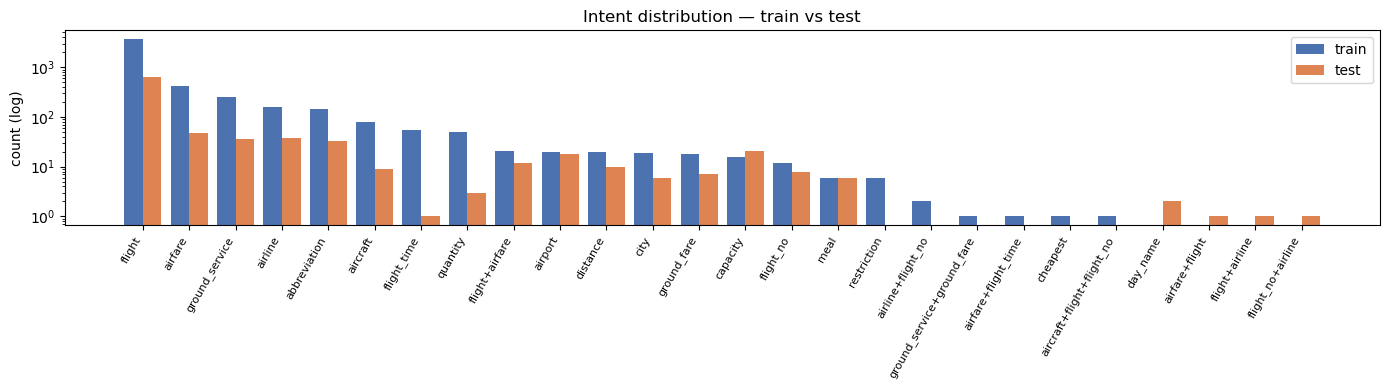

In [45]:
# ── full intent distribution (train vs test) ─────────────────────────────────
train_counts = train_df["intent"].value_counts()
test_counts = test_df["intent"].value_counts()

dist = (
    pd.concat(
        [train_counts.rename("train"), test_counts.rename("test")],
        axis=1,
    )
    .fillna(0)
    .astype(int)
)
dist["train_%"] = (dist["train"] / dist["train"].sum() * 100).round(2)
dist["test_%"] = (dist["test"] / dist["test"].sum() * 100).round(2)
dist = dist.sort_values("train", ascending=False)
display(dist)

# Imbalance summary
majority = dist.iloc[0]
n_train_total = dist["train"].sum()
n_classes_in_tr = (dist["train"] > 0).sum()
trivial_acc = majority["train"] / n_train_total
imbalance_ratio = dist[dist["train"] > 0]["train"].max() / dist[dist["train"] > 0]["train"].min()

print(
    f"\n{n_classes_in_tr} intents are present in training\n"
    f"Most common : {majority.name!r}  ({majority['train']:,} / {n_train_total:,} = {trivial_acc:.1%})\n"
    f"Imbalance ratio (max/min train count): {imbalance_ratio:,.0f}:1\n"
    f"→ a 'majority-class' dummy classifier already reaches {trivial_acc:.1%} accuracy."
)

# ── log-scale bar chart ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
x = np.arange(len(dist))
ax.bar(x - 0.2, dist["train"], width=0.4, color="#4C72B0", label="train")
ax.bar(x + 0.2, dist["test"], width=0.4, color="#DD8452", label="test")
ax.set_xticks(x)
ax.set_xticklabels(dist.index, rotation=60, ha="right", fontsize=8)
ax.set_yscale("log")
ax.set_ylabel("count (log)")
ax.set_title("Intent distribution — train vs test")
ax.legend()
plt.tight_layout()
plt.show()

### 1.5.3 — Test-only intents

When **`INTENT_FILTER_SHARED_ONLY`** is `True` in the data-loading cell, both **train-only** and **test-only** intent names are already removed (we keep only intents that appear in **both** files). The code below is then mostly a **sanity check** — asymmetric lists should be empty and the “hard accuracy ceiling” from unlearnable test labels becomes **1.0** on the filtered test set.

If the flag is `False`, any intent that appears in **test** but not in **train** is unlearnable from this dataset. We find them with a simple set difference and quantify the cap they impose on achievable test accuracy.

In [46]:
# ── set difference finds test-only intents ───────────────────────────────────
train_intents = set(train_df["intent"])
test_intents = set(test_df["intent"])

test_only = sorted(test_intents - train_intents)
train_only = sorted(train_intents - test_intents)
shared = sorted(train_intents & test_intents)

print(f"Train-only intents ({len(train_only)}): {train_only}")
print(f"Test-only  intents ({len(test_only)}):  {test_only}")
print(f"Shared intents     ({len(shared)})")

# ── how many test rows land in an unlearnable bucket? ────────────────────────
test_only_mask = test_df["intent"].isin(test_only)
n_test_only_rows = int(test_only_mask.sum())
n_test_rows = len(test_df)
ceiling_acc = 1.0 - n_test_only_rows / n_test_rows

print(
    f"\n{n_test_only_rows} / {n_test_rows} test rows ({n_test_only_rows / n_test_rows:.2%}) "
    f"belong to test-only intents.\n"
    f"=> Hard accuracy ceiling (perfect classifier on learnable classes): {ceiling_acc:.4f} ({ceiling_acc:.2%})"
)

# ── a few example utterances from each test-only intent ─────────────────────
print("\nExample utterances for each test-only intent:")
for it in test_only:
    samples = test_df.loc[test_df["intent"] == it, "text"].head(3).tolist()
    print(f"  • {it!r} (n={(test_df['intent'] == it).sum()}):")
    for s in samples:
        print(f"      - {s}")

Train-only intents (6): ['aircraft+flight+flight_no', 'airfare+flight_time', 'airline+flight_no', 'cheapest', 'ground_service+ground_fare', 'restriction']
Test-only  intents (4):  ['airfare+flight', 'day_name', 'flight+airline', 'flight_no+airline']
Shared intents     (16)

5 / 893 test rows (0.56%) belong to test-only intents.
=> Hard accuracy ceiling (perfect classifier on learnable classes): 0.9944 (99.44%)

Example utterances for each test-only intent:
  • 'airfare+flight' (n=1):
      - list the airfare for american airlines flight 19 from jfk to lax
  • 'day_name' (n=2):
      - what day of the week do flights from nashville to tacoma fly on
      - what days of the week do flights from san jose to nashville fly on
  • 'flight+airline' (n=1):
      - i need flight and airline information for a flight from denver to salt lake city on monday departing after 5 pm
  • 'flight_no+airline' (n=1):
      - i need flight numbers and airlines for flights departing from oakland to salt lake

### 1.5.4 — Intent ambiguity

Some queries have genuine label ambiguity — e.g., a question about "flight prices" could reasonably be `flight` or `airfare`. Two lightweight probes:

* **Exact-duplicate utterances labelled differently.**  
* **Keyword probes** (`price`, `cost`, `fare`) — see what distribution of intents those words land in.


'what' appears in 1517 utterances → intent distribution:
intent
flight            819
airfare           185
abbreviation      162
ground_service    106
airline            77
aircraft           60

'price' appears in 22 utterances → intent distribution:
intent
airfare        16
flight          4
ground_fare     2

'fare' appears in 296 utterances → intent distribution:
intent
airfare           181
abbreviation       70
flight             36
flight+airfare      4
quantity            1
cheapest            1

'cost' appears in 73 utterances → intent distribution:
intent
airfare                       55
flight                         8
ground_fare                    7
flight+airfare                 2
ground_service+ground_fare     1

'how much' appears in 51 utterances → intent distribution:
intent
airfare                       38
ground_fare                   10
ground_service                 1
ground_service+ground_fare     1
flight+airfare                 1

'cheapest' appears in 237 ut

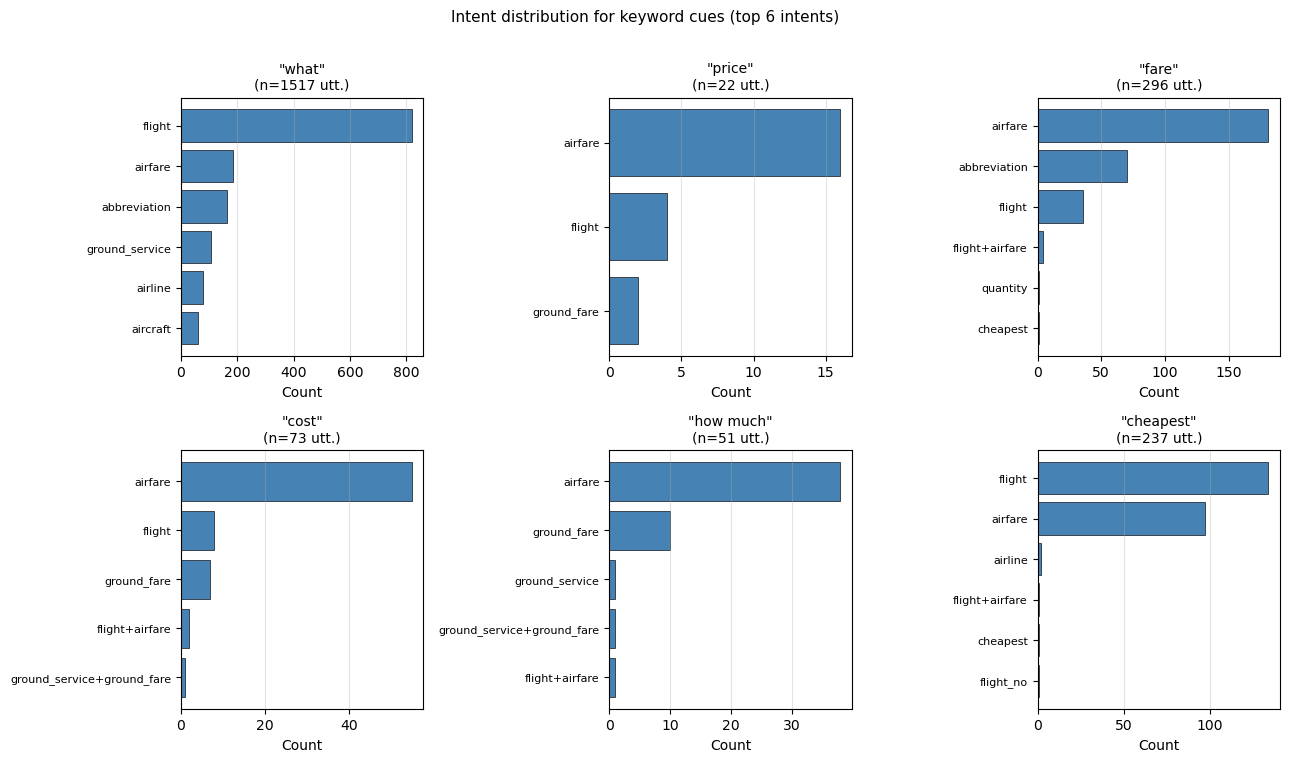


A few 'airfare' utterances that look awfully flight-like:
  - fares and flights from pittsburgh to philadelphia
  - what is the cost of a round trip flight from pittsburgh to atlanta beginning on april twenty fifth and returning on may sixth
  - can you show me economy class one way fares for flights from oakland to dallas on december sixteenth
  - what is the first class fare on united flight 352 from denver to boston
  - what is the fare from san francisco to dallas fort worth on delta flight 852


In [47]:
all_df = pd.concat([train_df.assign(split="train"), test_df.assign(split="test")])

# ── 1. keyword probes — which intents contain these money/price words? ────────
PROBE_KWS = ["what", "price", "fare", "cost", "how much", "cheapest"]
TOPN = 6
_probe_for_plot = []

for kw in PROBE_KWS:
    mask = all_df["text"].str.contains(rf"\b{kw}\b", case=False, regex=True)
    dist = all_df.loc[mask, "intent"].value_counts()
    top = dist.head(TOPN)
    _probe_for_plot.append((kw, int(mask.sum()), top))
    print(f"\n'{kw}' appears in {int(mask.sum())} utterances → intent distribution:")
    print(top.to_string())

# Same distributions as plots (for papers / slides)
fig_kw, axes_kw = plt.subplots(2, 3, figsize=(13, 7.5))
for ax, (kw, n_utt, top) in zip(axes_kw.ravel(), _probe_for_plot):
    if len(top) == 0:
        ax.text(0.5, 0.5, "no matches", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        continue
    y = np.arange(len(top))
    ax.barh(y, top.values, color="steelblue", edgecolor="black", linewidth=0.45)
    ax.set_yticks(y)
    ax.set_yticklabels(list(top.index), fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Count")
    short = kw if len(kw) < 18 else kw[:15] + "…"
    ax.set_title(f'"{short}"\n(n={n_utt} utt.)', fontsize=10)
    ax.grid(True, axis="x", alpha=0.35)
plt.suptitle("Intent distribution for keyword cues (top 6 intents)", y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

# ── 2. flight vs airfare specifically ─────────────────────────────────────────
print("\nA few 'airfare' utterances that look awfully flight-like:")
candidates = train_df[
    (train_df["intent"] == "airfare")
    & train_df["text"].str.contains(r"\b(?:flight|flights|fly|travel)\b", regex=True, case=False)
].head(5)
for t in candidates["text"].tolist():
    print(f"  - {t}")

### 1.5.5 — Domain vocabulary

ATIS contains a lot of *named entities* — city names, 3-letter airport codes, airline names, numeric flight/fare references. Those carry strong signal but also inflate vocabulary size and the OOV rate. We use the **dataset's own entity annotations** (`fromloc.city_name`, `airline_name`, `airport_code`, …) to build the lookup sets, instead of hardcoding them, then quantify:

* vocabulary size + Zipf-like tail,
* out-of-vocabulary (OOV) rate on the test split,
* share of vocab per entity bucket (cities / airlines / airport codes / airport names / states / numbers / general English).
* a **figure** plotting token-mass percentages by bucket, plus domain buckets **aggregated vs general English**.

The cell also exposes an opt-in **`MASK_ENTITIES`** set: list any of `"city"`, `"airline"`, `"airport-code"`, `"airport-name"`, `"state"`, `"date"`, `"time"`, `"numeric"` and the matching surface forms get replaced with `[city]` / `[airline]` / `[date]` / `[time]` / `[num]` / … in the word-level pipelines (TF-IDF LR + TextCNN word + TextCNN BPE). CharCNN keeps raw text. (BERT-style `[…]` brackets are used because they don't get eaten by HTML-aware renderers.)

The `date` bucket covers concrete date entities — weekdays (`monday`), day-numbers (`fourteenth`), months (`october`), years (`1993`), and `today`/`tomorrow`/`tonight`. The `time` bucket covers clock times (`noon`, `2 o'clock pm`, `1110`), periods of day (`morning`, `evening`), and `start_time`/`end_time` ranges. Ambiguous sub-types like `*.date_relative` / `*.time_relative` / `*.period_mod` (just generic words like `around`, `next`, `early`) are intentionally left unmasked.

**Per-pipeline toggles.** `MASK_ENTITIES` controls *which buckets* to mask. Two boolean flags decide *which pipelines* honor it (defaults `True`, so existing runs are unchanged):

* **`TFIDF_USE_MASKING`** (§3a, before `tfidf.fit`) — when `True`, the `TfidfVectorizer` uses `simple_tokenize` (collapse + mask); when `False` it falls back to sklearn's default word tokenizer on raw text.
* **`TEXTCNN_USE_MASKING`** (§4f, alongside `TOKENIZER_TYPE`) — when `True`, the selected `WordTokenizer` / `SentencePieceTokenizer` applies masking; when `False` it skips masking. The BPE cache is split into `atis_bpe_masked.model` vs `atis_bpe_raw.model` so flipping the flag automatically retrains a fresh BPE model. `CharTokenizer` ignores the flag (entity-level masking doesn't apply at the character level).

Entity sets from train annotations: 58 city names, 37 airline names + 13 airline codes, 42 airport names + 16 airport codes, 19 state names + 1 state codes.
Date/time entity sets: 86 date values (18 day-names, 46 day-numbers, 12 months, 4 years, 6 today-relative)  |  170 time values (116 clock-times, 15 periods-of-day, 20 start-times, 19 end-times).
Mask config : ['airline', 'airport-code', 'airport-name', 'city', 'date', 'numeric', 'state', 'time']
Train vocab :   519 unique tokens (53,350 total)
Test  vocab :   269 unique tokens (8,507 total)
OOV tokens on test: 53 / 8507 = 0.62%

Train-vocab composition:


,unique_types,total_tokens,share_tokens
general-english,511,38877,72.87
city,1,9144,17.14
date,1,2380,4.46
time,1,1441,2.70
airline,1,857,1.61
state,1,255,0.48
airport-name,1,167,0.31
numeric,1,165,0.31
airport-code,1,64,0.12


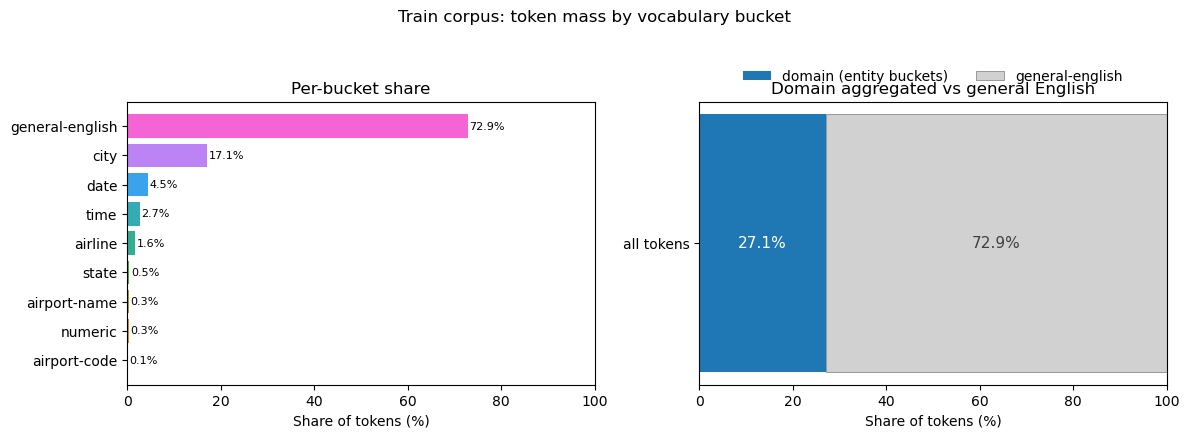


Masking effect (no-mask → masked):
  train vocab :  1002 →   519  (Δ -483)
  test  vocab :   473 →   269  (Δ -204)
  test  OOV   : 0.85% → 0.62%


In [48]:
from collections import Counter, defaultdict


# ── domain entity sets, derived from ATIS annotations (no hardcoded lists) ───
def collect_entity_values(json_path: Path) -> dict[str, set]:
    """Group every annotated span by its entity type (lowercased values)."""
    raw = json.loads(json_path.read_text(encoding="utf-8"))
    out: dict[str, set] = defaultdict(set)
    for ex in raw["rasa_nlu_data"]["common_examples"]:
        for ent in ex.get("entities", []):
            out[ent["entity"]].add(ent["value"].strip().lower())
    return dict(out)


# Train annotations only — test entities aren't peeked at.
ent2vals = collect_entity_values(TRAIN_JSON)


def gather(suffix: str) -> set:
    """Union all values whose entity type equals `suffix` or ends with `.suffix`."""
    bag: set = set()
    for k, v in ent2vals.items():
        if k == suffix or k.endswith("." + suffix):
            bag |= v
    return bag


known_cities = gather("city_name")  # fromloc.* / toloc.* / stoploc.* / city_name
known_airline_names = gather("airline_name")  # e.g. "american airlines"
known_airline_codes = gather("airline_code")  # e.g. "twa", "dl", "ua"
known_airport_names = gather("airport_name")  # e.g. "love field"
known_airport_codes = gather("airport_code")  # e.g. "ewr", "sfo"
known_state_names = gather("state_name")  # e.g. "north carolina"
known_state_codes = gather("state_code")  # e.g. "dc"

# Date/time entities (depart_date.*, arrive_date.*, return_date.*, depart_time.*, …).
# We keep only concrete sub-types and skip the ambiguous "*.date_relative" /
# "*.time_relative" / "*.period_mod" buckets — those are just common adverbs
# like "around", "next", "early" and masking them would hurt more than help.
known_day_names = gather("day_name")  # weekdays:   "monday", "fridays"
known_day_numbers = gather("day_number")  # ordinals:   "fourteenth", "twenty ninth"
known_month_names = gather("month_name")  # months:     "may", "october"
known_years = gather("year")  # years:      "1993", "1991"
known_today_rel = gather("today_relative")  # day-words:  "today", "tomorrow", "tonight"
known_times = gather("time")  # clock:      "noon", "2 o'clock pm", "1110"
known_periods = gather("period_of_day")  # periods:    "morning", "afternoon", "midnight"
known_start_times = gather("start_time")  # range start "5 pm", "noon"
known_end_times = gather("end_time")  # range end   "10 pm", "5 o'clock"

print(
    "Entity sets from train annotations: "
    f"{len(known_cities)} city names, "
    f"{len(known_airline_names)} airline names + {len(known_airline_codes)} airline codes, "
    f"{len(known_airport_names)} airport names + {len(known_airport_codes)} airport codes, "
    f"{len(known_state_names)} state names + {len(known_state_codes)} state codes."
)
_n_date = sum(
    map(len, [known_day_names, known_day_numbers, known_month_names, known_years, known_today_rel])
)
_n_time = sum(map(len, [known_times, known_periods, known_start_times, known_end_times]))
print(
    f"Date/time entity sets: {_n_date} date values "
    f"({len(known_day_names)} day-names, {len(known_day_numbers)} day-numbers, "
    f"{len(known_month_names)} months, {len(known_years)} years, "
    f"{len(known_today_rel)} today-relative)  |  "
    f"{_n_time} time values "
    f"({len(known_times)} clock-times, {len(known_periods)} periods-of-day, "
    f"{len(known_start_times)} start-times, {len(known_end_times)} end-times)."
)

NUMERIC = re.compile(r"^\d+$")

# ── collapse multi-word entity spans into single tokens BEFORE tokenising ────
# e.g. "fly from san francisco to new york via love field" →
#      "fly from san_francisco to new_york via love_field"
_multiword_phrases = sorted(
    {
        p
        for s in (
            known_cities,
            known_airline_names,
            known_airport_names,
            known_state_names,
            # date/time multi-word values: "twenty ninth", "the day after tomorrow",
            # "2 o'clock pm", "11 pm", "1115 am", "lunch time", …
            known_day_names,
            known_day_numbers,
            known_month_names,
            known_today_rel,
            known_times,
            known_periods,
            known_start_times,
            known_end_times,
        )
        for p in s
        if " " in p
    },
    key=len,
    reverse=True,  # longest first → "san francisco" wins over "san"
)
_MULTI_RE = (
    re.compile(
        r"\b(?:" + "|".join(re.escape(p) for p in _multiword_phrases) + r")\b",
        flags=re.IGNORECASE,
    )
    if _multiword_phrases
    else None
)

_WORD_CHUNK = re.compile(r"[a-zA-Z0-9]+")


def _collapse_multiword(text: str) -> str:
    if _MULTI_RE is None:
        return text
    # drop intra-phrase punctuation ("st. louis" → "st_louis")
    return _MULTI_RE.sub(
        lambda m: "_".join(_WORD_CHUNK.findall(m.group(0).lower())),
        text,
    )


# Match (1) bracketed mask placeholders like "[city]" / "[airport_code]"
# (kept atomic so masking survives tokenization), (2) word/number tokens
# allowing both letters, digits and underscores in the same token so collapsed
# multi-word phrases ("san_francisco", "838_am", "2_o_clock_pm") survive as a
# single token and can be looked up in date_tok / time_tok / cities_tok / …
_WORD_RE = re.compile(r"\[[a-z_]+\]|[a-zA-Z0-9_]+")


# token-shape lookups for bucketing (multi-word phrases joined with "_")
def _to_token(p: str) -> str:
    return "_".join(_WORD_CHUNK.findall(p.lower()))


cities_tok = {_to_token(c) for c in known_cities}
airlines_tok = {_to_token(a) for a in known_airline_names | known_airline_codes}
airport_codes_tok = {_to_token(a) for a in known_airport_codes}
airport_names_tok = {_to_token(a) for a in known_airport_names}
states_tok = {_to_token(s) for s in known_state_names | known_state_codes}
date_tok = (
    {_to_token(d) for d in known_day_names}
    | {_to_token(d) for d in known_day_numbers}
    | {_to_token(d) for d in known_month_names}
    | {_to_token(d) for d in known_years}
    | {_to_token(d) for d in known_today_rel}
)
time_tok = (
    {_to_token(t) for t in known_times}
    | {_to_token(t) for t in known_periods}
    | {_to_token(t) for t in known_start_times}
    | {_to_token(t) for t in known_end_times}
)


def bucket(w: str) -> str:
    # date/time take priority over the generic "numeric" bucket so that
    # year tokens like "1993" become [date] and clock tokens like "1110"
    # become [time], rather than collapsing to the catch-all [num].
    if w in date_tok:
        return "date"
    if w in time_tok:
        return "time"
    if NUMERIC.match(w):
        return "numeric"
    if w in cities_tok:
        return "city"
    if w in airlines_tok:
        return "airline"
    if w in airport_codes_tok:
        return "airport-code"
    if w in airport_names_tok:
        return "airport-name"
    if w in states_tok:
        return "state"
    return "general-english"


# ── entity masking (opt-in) ──────────────────────────────────────────────────
# Add bucket names to enable masking; e.g. {"city", "airline"} replaces every
# annotated city surface form with "[city]" and every airline with "[airline]".
# Choices: "city" | "airline" | "airport-code" | "airport-name" | "state"
#        | "date" | "time" | "numeric"
# Affects TF-IDF LR + TextCNN word/BPE pipelines (gated per pipeline by
# TFIDF_USE_MASKING / TEXTCNN_USE_MASKING); CharCNN always sees raw text.
# We use BERT-style "[…]" placeholders (cf. [CLS], [SEP], [MASK]) instead of
# "<…>" so they don't collide with HTML rendering in pandas / Jupyter / READMEs.
MASK_ENTITIES: set = {
    "city",
    "airline",
    "airport-code",
    "airport-name",
    "state",
    "date",
    "time",
    "numeric",
}

_MASK_TOKEN = {
    "city": "[city]",
    "airline": "[airline]",
    "airport-code": "[airport_code]",
    "airport-name": "[airport_name]",
    "state": "[state]",
    "date": "[date]",
    "time": "[time]",
    "numeric": "[num]",
}


def _mask_token(tok: str) -> str:
    """Return placeholder if `tok` belongs to an enabled bucket, else `tok`."""
    if not MASK_ENTITIES:
        return tok
    b = bucket(tok)
    return _MASK_TOKEN[b] if b in MASK_ENTITIES else tok


def simple_tokenize(text: str):
    toks = _WORD_RE.findall(_collapse_multiword(text).lower())
    return [_mask_token(t) for t in toks] if MASK_ENTITIES else toks


# ── build vocabulary ─────────────────────────────────────────────────────────
train_tokens = [t for txt in train_df["text"] for t in simple_tokenize(txt)]
test_tokens = [t for txt in test_df["text"] for t in simple_tokenize(txt)]

tr_vocab = Counter(train_tokens)
te_vocab = Counter(test_tokens)

oov_tokens = sum(c for w, c in te_vocab.items() if w not in tr_vocab)
total_test = sum(te_vocab.values())

print(f"Mask config : {sorted(MASK_ENTITIES) or '(none)'}")
print(f"Train vocab : {len(tr_vocab):>5} unique tokens ({sum(tr_vocab.values()):,} total)")
print(f"Test  vocab : {len(te_vocab):>5} unique tokens ({total_test:,} total)")
print(f"OOV tokens on test: {oov_tokens} / {total_test} = {oov_tokens / total_test:.2%}")


# ── bucketing & report (annotated entity sets, no regex heuristics) ──────────
def _vocab_bucket(w: str) -> str:
    """Bucket a vocab token, accounting for any active mask placeholders."""
    for cat, tok in _MASK_TOKEN.items():
        if w == tok:
            return cat
    return bucket(w)


bucket_counts = Counter(_vocab_bucket(w) for w in tr_vocab)
bucket_rows = Counter()
for w, c in tr_vocab.items():
    bucket_rows[_vocab_bucket(w)] += c

bucket_df = (
    pd.DataFrame(
        {
            "unique_types": pd.Series(bucket_counts),
            "total_tokens": pd.Series(bucket_rows),
        }
    )
    .fillna(0)
    .astype(int)
)
bucket_df["share_tokens"] = (
    bucket_df["total_tokens"] / bucket_df["total_tokens"].sum() * 100
).round(2)
print("\nTrain-vocab composition:")
display(bucket_df.sort_values("total_tokens", ascending=False))

_bf = bucket_df.sort_values("share_tokens", ascending=True)
_gen = float(_bf.loc["general-english", "share_tokens"]) if "general-english" in _bf.index else 0.0
_dom = float(_bf["share_tokens"].sum() - _gen)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.25))
fig.suptitle(
    "Train corpus: token mass by vocabulary bucket",
    fontsize=12,
    y=1.02,
)
_cols = sns.color_palette("husl", n_colors=len(_bf))
axes[0].barh(_bf.index.astype(str), _bf["share_tokens"], color=_cols)
axes[0].set_xlabel("Share of tokens (%)")
axes[0].set_title("Per-bucket share")
axes[0].set_xlim(0, max(100, float(_bf["share_tokens"].max()) * 1.18))
for y, (_, row) in enumerate(_bf.iterrows()):
    axes[0].text(
        float(row["share_tokens"]) + 0.35,
        y,
        f"{float(row['share_tokens']):.1f}%",
        va="center",
        fontsize=8,
    )

axes[1].barh([0], _dom, left=0, color="C0", label="domain (entity buckets)")
axes[1].barh(
    [0], _gen, left=_dom, color="0.82", edgecolor="0.55", linewidth=0.6, label="general-english"
)
axes[1].set_yticks([0])
axes[1].set_yticklabels(["all tokens"])
axes[1].set_xlim(0, 100)
axes[1].set_xlabel("Share of tokens (%)")
axes[1].set_title("Domain aggregated vs general English")
axes[1].legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False)
if _dom > 4:
    axes[1].text(_dom / 2, 0, f"{_dom:.1f}%", ha="center", va="center", fontsize=11, color="white")
if _gen > 4:
    axes[1].text(
        _dom + _gen / 2, 0, f"{_gen:.1f}%", ha="center", va="center", fontsize=11, color="0.25"
    )
plt.tight_layout()
plt.show()

# print("\nHigh-frequency domain examples:")
# for cat in ["city", "airline", "airport-code", "airport-name", "state",
#             "date", "time", "numeric"]:
#     top = sorted(
#         ((w, tr_vocab[w]) for w in tr_vocab if _vocab_bucket(w) == cat),
#         key=lambda x: -x[1],
#     )[:10]
#     if top:
#         print(f"  {cat:>18s}: {top}")

# ── before/after delta when masking is enabled ───────────────────────────────
if MASK_ENTITIES:
    _saved = set(MASK_ENTITIES)
    MASK_ENTITIES.clear()
    try:
        _raw_train = [t for txt in train_df["text"] for t in simple_tokenize(txt)]
        _raw_test = [t for txt in test_df["text"] for t in simple_tokenize(txt)]
    finally:
        MASK_ENTITIES.update(_saved)

    _raw_tr = Counter(_raw_train)
    _raw_te = Counter(_raw_test)
    _raw_oov = sum(c for w, c in _raw_te.items() if w not in _raw_tr)
    _raw_total = sum(_raw_te.values())

    print("\nMasking effect (no-mask → masked):")
    print(
        f"  train vocab : {len(_raw_tr):>5} → {len(tr_vocab):>5}  "
        f"(Δ {len(tr_vocab) - len(_raw_tr):+d})"
    )
    print(
        f"  test  vocab : {len(_raw_te):>5} → {len(te_vocab):>5}  "
        f"(Δ {len(te_vocab) - len(_raw_te):+d})"
    )
    print(f"  test  OOV   : {_raw_oov / _raw_total:.2%} → {oov_tokens / total_test:.2%}")

### 1.5.6 — Semantic similarity between related intents

Intents like `flight`, `flight_time`, `flight_no` share most of their vocabulary. We quantify that overlap with Jaccard similarity on per-intent word sets, and look at the discriminative keywords (rare in `flight`, common in the sibling).

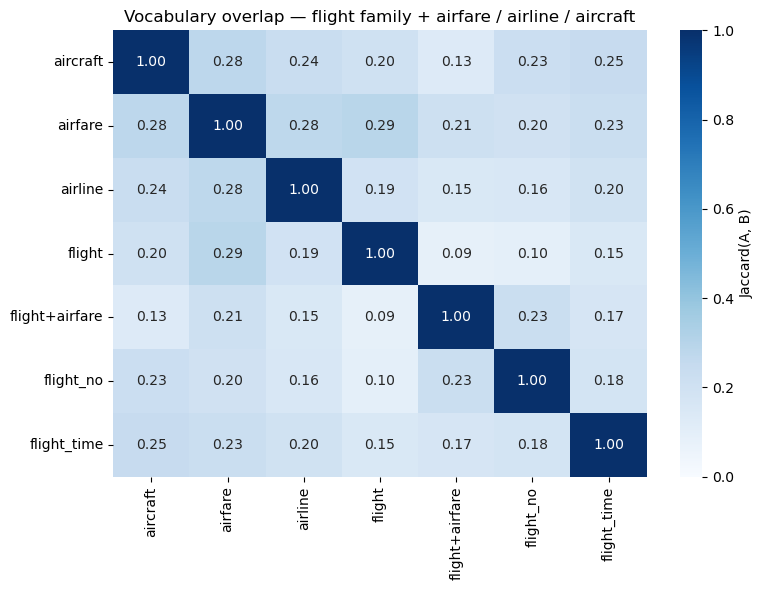

Top-10 most vocabulary-similar intent pairs (train):
  0.290   airfare                 ↔  flight
  0.278   aircraft                ↔  airfare
  0.277   airfare                 ↔  airline
  0.269   airline                 ↔  quantity
  0.267   ground_fare             ↔  ground_service+ground_fare
  0.248   aircraft                ↔  flight_time
  0.244   flight+airfare          ↔  restriction
  0.242   flight_time             ↔  quantity
  0.239   airfare                 ↔  ground_service
  0.235   aircraft                ↔  airline


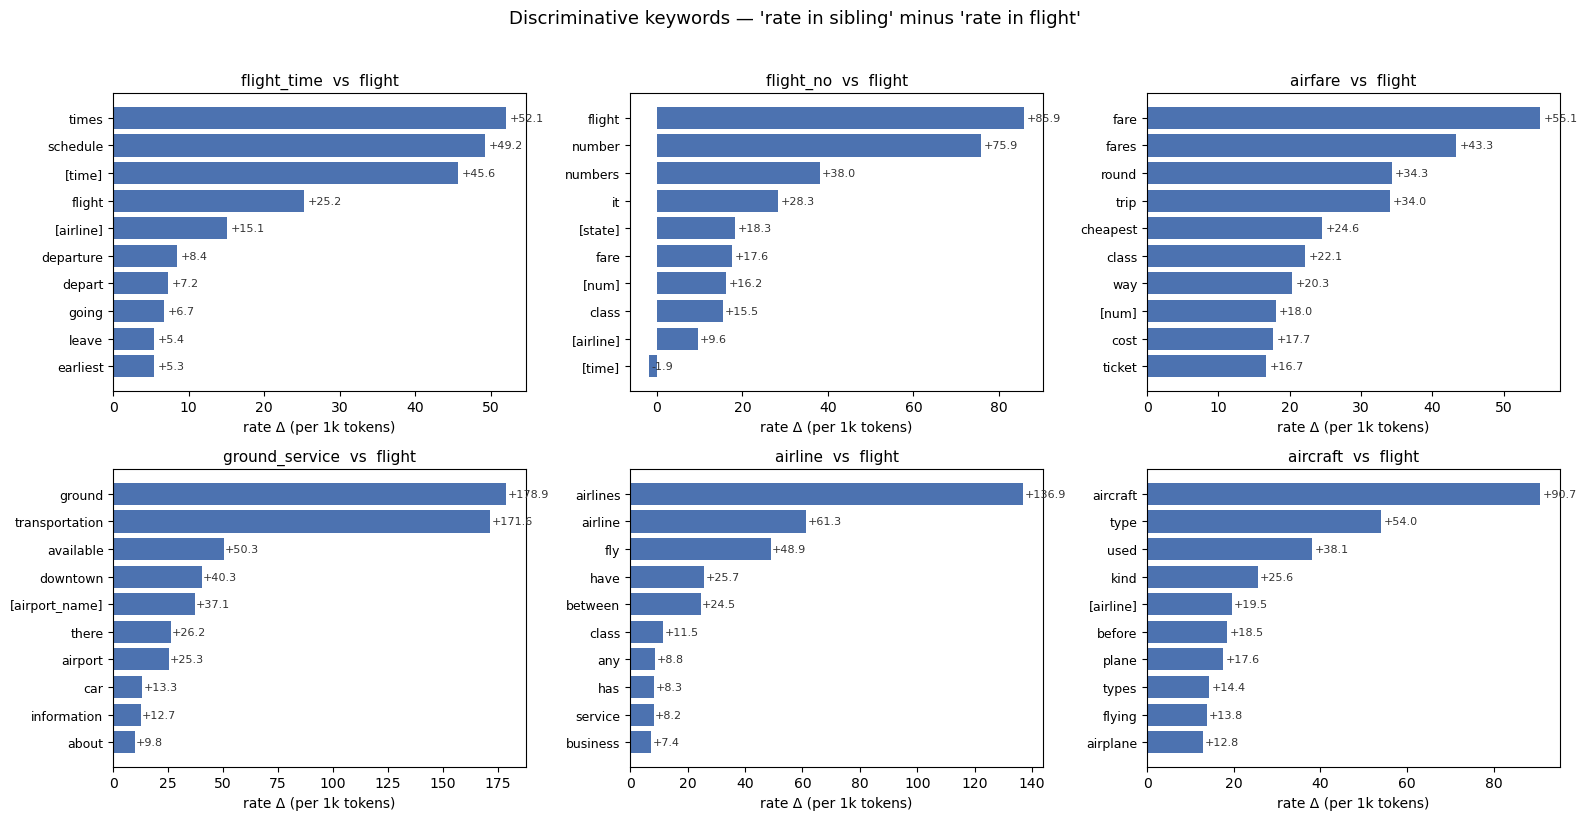

In [49]:
# ── per-intent token sets (train only) ───────────────────────────────────────
STOPWORDS = {
    "the",
    "a",
    "an",
    "of",
    "to",
    "from",
    "on",
    "in",
    "for",
    "is",
    "are",
    "what",
    "which",
    "me",
    "show",
    "list",
    "give",
    "i",
    "please",
    "do",
    "does",
    "can",
    "my",
    "and",
    "all",
    "that",
    "with",
    "at",
    "be",
    "would",
}


def token_set(series: pd.Series):
    toks = [t for text in series for t in simple_tokenize(text)]
    return {t for t in toks if t not in STOPWORDS and not t.isnumeric()}


intent_tokens = {
    it: token_set(train_df.loc[train_df["intent"] == it, "text"]) for it in train_intents
}

# ── 1. Jaccard similarity matrix — flight family + airfare/airline/aircraft ──
siblings = [
    it
    for it in sorted(train_intents)
    if it.startswith("flight") or it in {"airfare", "airline", "aircraft"}
]


def jaccard(a: set, b: set) -> float:
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)


J = pd.DataFrame(
    [[jaccard(intent_tokens[i], intent_tokens[j]) for j in siblings] for i in siblings],
    index=siblings,
    columns=siblings,
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    J,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    ax=ax,
    cbar_kws={"label": "Jaccard(A, B)"},
)
ax.set_title("Vocabulary overlap — flight family + airfare / airline / aircraft")
plt.tight_layout()
plt.show()

# ── 2. most-similar intent pairs across ALL intents ──────────────────────────
pair_scores = []
intents_sorted = sorted(train_intents)
for i in range(len(intents_sorted)):
    for j in range(i + 1, len(intents_sorted)):
        a, b = intents_sorted[i], intents_sorted[j]
        pair_scores.append((a, b, jaccard(intent_tokens[a], intent_tokens[b])))
pair_scores.sort(key=lambda x: -x[2])

print("Top-10 most vocabulary-similar intent pairs (train):")
for a, b, s in pair_scores[:10]:
    print(f"  {s:.3f}   {a:<22s}  ↔  {b}")


# ── 3. discriminative keywords (visual): sibling vs. flight ──────────────────
def discriminative_words(target: str, base: str = "flight", topk: int = 10):
    """Words common in `target` but rare in `base`, ranked by rate-delta per-1k tokens."""
    target_texts = train_df.loc[train_df["intent"] == target, "text"]
    base_texts = train_df.loc[train_df["intent"] == base, "text"]
    if len(target_texts) == 0:
        return []
    tgt = Counter(t for txt in target_texts for t in simple_tokenize(txt) if t not in STOPWORDS)
    bas = Counter(t for txt in base_texts for t in simple_tokenize(txt) if t not in STOPWORDS)
    tgt_rate = {w: c / sum(tgt.values()) * 1000 for w, c in tgt.items()}
    bas_rate = {w: bas.get(w, 0) / max(sum(bas.values()), 1) * 1000 for w in tgt}
    scored = sorted(
        ((w, tgt_rate[w] - bas_rate[w]) for w in tgt if tgt[w] >= 2),
        key=lambda x: -x[1],
    )[:topk]
    return scored


sibling_list = [
    s
    for s in ["flight_time", "flight_no", "airfare", "ground_service", "airline", "aircraft"]
    if s in train_intents
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False)
axes = axes.flatten()
for ax, sib in zip(axes, sibling_list):
    kws = discriminative_words(sib, base="flight", topk=10)
    if not kws:
        ax.set_visible(False)
        continue
    words = [w for w, _ in kws][::-1]  # reverse so largest is on top
    scores = [s for _, s in kws][::-1]
    bars = ax.barh(words, scores, color="#4C72B0")
    ax.set_title(f"{sib}  vs  flight", fontsize=11)
    ax.set_xlabel("rate Δ (per 1k tokens)")
    ax.tick_params(axis="y", labelsize=9)
    for bar, score in zip(bars, scores):
        ax.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f"{score:+.1f}",
            va="center",
            fontsize=8,
            color="#333",
        )

for ax in axes[len(sibling_list) :]:
    ax.set_visible(False)
fig.suptitle(
    "Discriminative keywords — 'rate in sibling' minus 'rate in flight'", fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

### 1.5.7 — Tokenization preview

Two side-by-side tables (word-level and BPE) showing how each tokenizer splits ATIS utterances and how the resulting tokens line up with the pretrained GloVe vocabulary.

Each table has four columns:

- **utterance** — raw input text  
- **no mask** — tokens with masking off  
- **masked** — tokens with all entity buckets masked (`[city]`, `[airline]`, `[date]`, `[time]`, `[num]`, …)  
- **embedded (GloVe, first 5 dims)** — what the embedding layer actually feeds the model for the masked tokens:
  - `tok:[+0.05, +0.13, +0.27, +0.41, -0.22]` → first 5 of 100 GloVe dims (pretrained vector)
  - `tok:✗rand` → no GloVe vector (random init, learned from scratch)
  - `tok:★rand` → mask placeholder (no GloVe; learned from scratch but stands in for a whole entity class)

The BPE preview model is trained on the fly with `user_defined_symbols` so placeholders stay atomic in the vocab.

In [50]:
# ── 1.5.7 Tokenization preview ───────────────────────────────────────────────

# Pick 5 random utterances from the training set.
_PREVIEW_TEXTS = train_df["text"].sample(n=5, random_state=42).tolist()

_PLACEHOLDERS = [
    "[city]",
    "[airline]",
    "[num]",
    "[date]",
    "[time]",
    "[airport_code]",
    "[airport_name]",
    "[state]",
]
_ALL_MASKS = {"city", "airline", "airport-code", "airport-name", "state", "date", "time", "numeric"}

# ── BPE: train a small preview model on the full training corpus ─────────────
# user_defined_symbols keeps placeholder tokens atomic — without this the BPE
# model would split "[city]" into "[", "c", "it", "y", "]".
_spm_dir = ROOT / "notebooks" / ".spm"
_spm_dir.mkdir(parents=True, exist_ok=True)
_spm_prefix = str(_spm_dir / "atis_bpe_preview_v4")
_spm_model = _spm_prefix + ".model"

if not Path(_spm_model).exists():
    print("Training preview BPE model (vocab=800, user_defined_symbols on) …")
    spm.SentencePieceTrainer.train(
        sentence_iterator=iter(train_df["text"].tolist()),
        model_prefix=_spm_prefix,
        vocab_size=800,
        model_type="bpe",
        pad_id=0,
        unk_id=1,
        bos_id=-1,
        eos_id=-1,
        character_coverage=1.0,
        user_defined_symbols=_PLACEHOLDERS,
    )
    print("[done]", _spm_model)

_sp = spm.SentencePieceProcessor()
_sp.load(_spm_model)

# ── GloVe (cached after first call) ──────────────────────────────────────────
_glove = load_glove_vectors("6B", 100, cache=ROOT / ".vector_cache")


# ── tokenizer helpers ────────────────────────────────────────────────────────
def _with_mask(masks, fn):
    """Run `fn()` with MASK_ENTITIES temporarily set to `masks`, then restore."""
    _saved = set(MASK_ENTITIES)
    MASK_ENTITIES.clear()
    MASK_ENTITIES.update(masks)
    try:
        return fn()
    finally:
        MASK_ENTITIES.clear()
        MASK_ENTITIES.update(_saved)


def _word_no_mask(text):
    return _with_mask(set(), lambda: simple_tokenize(text))


def _word_masked(text):
    return _with_mask(_ALL_MASKS, lambda: simple_tokenize(text))


# Note: SentencePiece prefixes word-initial pieces with "▁" (U+2581 LOWER ONE
# EIGHTH BLOCK) as a *visible whitespace marker*, so tokenization is fully
# reversible: "".join(pieces).replace("▁", " ") gives back the original text.
# Pieces without "▁" are sub-word continuations of the previous piece.
def _bpe_no_mask(text):
    return _sp.encode(text, out_type=str)


def _bpe_masked(text):
    return _sp.encode(" ".join(_word_masked(text)), out_type=str)


# ── GloVe annotation: show first 5 dims of the embedding lookup ──────────────
# For tokens that hit GloVe, render the first 5 dimensions of the pretrained
# vector (the model uses all 100 — these 5 are just a teaser).  For mask
# placeholders and OOV tokens we show `★rand` / `✗rand` since the embedding
# layer initialises those rows randomly and learns them from scratch.
def _glove_first(tok: str) -> str:
    if tok.startswith("[") and tok.endswith("]") and len(tok) > 2:
        return f"{tok}:★rand"
    lookup = tok.lstrip("▁")  # strip BPE word-boundary marker for lookup
    if lookup in _glove.stoi:
        v = _glove.vectors[_glove.stoi[lookup]][:3].tolist()
        return f"{tok}:[" + ", ".join(f"{x:+.2f}" for x in v) + "]"
    return f"{tok}:✗rand"


def _coverage(tokens):
    hits = sum(1 for t in tokens if t.lstrip("▁") in _glove.stoi)
    return hits, len(tokens)


def _fmt(tokens):
    return " | ".join(tokens)


def _fmt_embedded(tokens):
    return " | ".join(_glove_first(t) for t in tokens)


# ── build the two tables and accumulate coverage stats ───────────────────────
def _build_table(tokenize_no_mask, tokenize_masked):
    rows, hits_nm, n_nm, hits_m, n_m = [], 0, 0, 0, 0
    for txt in _PREVIEW_TEXTS:
        nm = tokenize_no_mask(txt)
        m = tokenize_masked(txt)
        h1, t1 = _coverage(nm)
        hits_nm += h1
        n_nm += t1
        h2, t2 = _coverage(m)
        hits_m += h2
        n_m += t2
        rows.append(
            {
                "utterance": txt,
                "no mask": _fmt(nm),
                "masked": _fmt(m),
                "embedded (GloVe, first 5 dims)": _fmt_embedded(m),
            }
        )
    return pd.DataFrame(rows).set_index("utterance"), (hits_nm, n_nm, hits_m, n_m)


word_df, word_cov = _build_table(_word_no_mask, _word_masked)
bpe_df, bpe_cov = _build_table(_bpe_no_mask, _bpe_masked)


# ── styling helper ───────────────────────────────────────────────────────────
def _style(df, caption):
    return (
        df.style.format(
            escape="html"
        )  # defensive: harmless for "[city]", critical if anything stray contains "<>"
        .set_caption(caption)
        .set_properties(
            **{
                "text-align": "left",
                "white-space": "pre-wrap",
                "font-size": "12px",
                "min-width": "160px",
            }
        )
        .set_table_styles(
            [
                {"selector": "th", "props": [("text-align", "left"), ("font-size", "12px")]},
                {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px")]},
            ]
        )
    )


# ── display ──────────────────────────────────────────────────────────────────
pd.set_option("display.max_colwidth", 130)
pd.set_option("display.width", 400)
display(
    _style(
        word_df,
        "Word-level tokenization — utterance, no mask, masked, embedded (GloVe first 3 dims)",
    )
)
display(
    _style(bpe_df, "BPE tokenization — utterance, no mask, masked, embedded (GloVe first 3 dims)")
)


# ── stats ────────────────────────────────────────────────────────────────────
def _pct(h, n):
    return f"{h}/{n} ({h / n:.0%})" if n else "0/0"


print("Embedded-column legend:")
print("  tok:[d1, d2, d3]         = first 3 of 100 GloVe dims (pretrained vector)")
print("  tok:✗rand                = no GloVe vector (random init, learned from scratch)")
print("  tok:★rand                = mask placeholder, e.g. [city] (no GloVe; learned from scratch)")
print()
print("GloVe coverage on preview utterances:")
print(f"  word (no mask): {_pct(word_cov[0], word_cov[1])}")
print(f"  word (masked):  {_pct(word_cov[2], word_cov[3])}")
print(f"  BPE  (no mask): {_pct(bpe_cov[0], bpe_cov[1])}")
print(f"  BPE  (masked):  {_pct(bpe_cov[2], bpe_cov[3])}")

print(
    f"\nBPE vocab size: {_sp.get_piece_size()} "
    f"(includes {len(_PLACEHOLDERS)} user_defined_symbols kept atomic)"
)
print(f"GloVe loaded: {len(_glove.stoi):,} vectors")

,no mask,masked,"embedded (GloVe, first 5 dims)"
utterance,,,
i want to make a round trip flight from washington to san francisco and return,i | want | to | make | a | round | trip | flight | from | washington | to | san_francisco | and | return,i | want | to | make | a | round | trip | flight | from | [city] | to | [city] | and | return,"i:[-0.05, +0.62, +0.57] | want:[-0.17, +0.56, +0.35] | to:[-0.19, +0.05, +0.19] | make:[-0.33, +0.07, +0.35] | a:[-0.27, +0.04, -0.02] | round:[-0.72, +0.04, +0.47] | trip:[-0.67, -0.33, +0.96] | flight:[+0.12, -0.66, +0.51] | from:[+0.31, +0.25, +0.68] | [city]:★rand | to:[-0.19, +0.05, +0.19] | [city]:★rand | and:[-0.07, +0.23, +0.02] | return:[+0.10, -0.20, +0.21]"
what are the coach fares from charlotte to la wednesday night,what | are | the | coach | fares | from | charlotte | to | la | wednesday | night,what | are | the | coach | fares | from | [city] | to | [city] | [date] | [time],"what:[-0.15, +0.38, +0.89] | are:[-0.52, +0.83, +0.22] | the:[-0.04, -0.24, +0.73] | coach:[+0.53, +0.20, +0.75] | fares:[-0.72, -0.58, -0.38] | from:[+0.31, +0.25, +0.68] | [city]:★rand | to:[-0.19, +0.05, +0.19] | [city]:★rand | [date]:★rand | [time]:★rand"
now i need a flight from detroit to san diego leaving tuesday evening,now | i | need | a | flight | from | detroit | to | san_diego | leaving | tuesday | evening,now | i | need | a | flight | from | [city] | to | [city] | leaving | [date] | [time],"now:[-0.01, +0.59, +0.70] | i:[-0.05, +0.62, +0.57] | need:[-0.25, +0.91, +0.36] | a:[-0.27, +0.04, -0.02] | flight:[+0.12, -0.66, +0.51] | from:[+0.31, +0.25, +0.68] | [city]:★rand | to:[-0.19, +0.05, +0.19] | [city]:★rand | leaving:[-0.11, -0.27, +0.44] | [date]:★rand | [time]:★rand"
houston airports,houston | airports,[city] | airports,"[city]:★rand | airports:[-0.14, -0.34, +0.03]"
show me the cheapest one way fares from san diego to miami,show | me | the | cheapest | one | way | fares | from | san_diego | to | miami,show | me | the | cheapest | [date] | way | fares | from | [city] | to | [city],"show:[+0.11, -0.14, +0.06] | me:[+0.06, +0.13, +0.73] | the:[-0.04, -0.24, +0.73] | cheapest:[-0.19, +0.74, +1.08] | [date]:★rand | way:[+0.16, +0.22, +0.67] | fares:[-0.72, -0.58, -0.38] | from:[+0.31, +0.25, +0.68] | [city]:★rand | to:[-0.19, +0.05, +0.19] | [city]:★rand"


,no mask,masked,"embedded (GloVe, first 5 dims)"
utterance,,,
i want to make a round trip flight from washington to san francisco and return,▁i | ▁want | ▁to | ▁make | ▁a | ▁round | ▁trip | ▁flight | ▁from | ▁washington | ▁to | ▁san | ▁francisco | ▁and | ▁return,▁i | ▁want | ▁to | ▁make | ▁a | ▁round | ▁trip | ▁flight | ▁from | ▁ | [city] | ▁to | ▁ | [city] | ▁and | ▁return,"▁i:[-0.05, +0.62, +0.57] | ▁want:[-0.17, +0.56, +0.35] | ▁to:[-0.19, +0.05, +0.19] | ▁make:[-0.33, +0.07, +0.35] | ▁a:[-0.27, +0.04, -0.02] | ▁round:[-0.72, +0.04, +0.47] | ▁trip:[-0.67, -0.33, +0.96] | ▁flight:[+0.12, -0.66, +0.51] | ▁from:[+0.31, +0.25, +0.68] | ▁:✗rand | [city]:★rand | ▁to:[-0.19, +0.05, +0.19] | ▁:✗rand | [city]:★rand | ▁and:[-0.07, +0.23, +0.02] | ▁return:[+0.10, -0.20, +0.21]"
what are the coach fares from charlotte to la wednesday night,▁what | ▁are | ▁the | ▁coach | ▁fares | ▁from | ▁charlotte | ▁to | ▁la | ▁wednesday | ▁night,▁what | ▁are | ▁the | ▁coach | ▁fares | ▁from | ▁ | [city] | ▁to | ▁ | [city] | ▁ | [date] | ▁ | [time],"▁what:[-0.15, +0.38, +0.89] | ▁are:[-0.52, +0.83, +0.22] | ▁the:[-0.04, -0.24, +0.73] | ▁coach:[+0.53, +0.20, +0.75] | ▁fares:[-0.72, -0.58, -0.38] | ▁from:[+0.31, +0.25, +0.68] | ▁:✗rand | [city]:★rand | ▁to:[-0.19, +0.05, +0.19] | ▁:✗rand | [city]:★rand | ▁:✗rand | [date]:★rand | ▁:✗rand | [time]:★rand"
now i need a flight from detroit to san diego leaving tuesday evening,▁now | ▁i | ▁need | ▁a | ▁flight | ▁from | ▁detroit | ▁to | ▁san | ▁diego | ▁leaving | ▁tuesday | ▁evening,▁now | ▁i | ▁need | ▁a | ▁flight | ▁from | ▁ | [city] | ▁to | ▁ | [city] | ▁leaving | ▁ | [date] | ▁ | [time],"▁now:[-0.01, +0.59, +0.70] | ▁i:[-0.05, +0.62, +0.57] | ▁need:[-0.25, +0.91, +0.36] | ▁a:[-0.27, +0.04, -0.02] | ▁flight:[+0.12, -0.66, +0.51] | ▁from:[+0.31, +0.25, +0.68] | ▁:✗rand | [city]:★rand | ▁to:[-0.19, +0.05, +0.19] | ▁:✗rand | [city]:★rand | ▁leaving:[-0.11, -0.27, +0.44] | ▁:✗rand | [date]:★rand | ▁:✗rand | [time]:★rand"
houston airports,▁houston | ▁airports,▁ | [city] | ▁airports,"▁:✗rand | [city]:★rand | ▁airports:[-0.14, -0.34, +0.03]"
show me the cheapest one way fares from san diego to miami,▁show | ▁me | ▁the | ▁cheapest | ▁one | ▁way | ▁fares | ▁from | ▁san | ▁diego | ▁to | ▁miami,▁show | ▁me | ▁the | ▁cheapest | ▁ | [date] | ▁way | ▁fares | ▁from | ▁ | [city] | ▁to | ▁ | [city],"▁show:[+0.11, -0.14, +0.06] | ▁me:[+0.06, +0.13, +0.73] | ▁the:[-0.04, -0.24, +0.73] | ▁cheapest:[-0.19, +0.74, +1.08] | ▁:✗rand | [date]:★rand | ▁way:[+0.16, +0.22, +0.67] | ▁fares:[-0.72, -0.58, -0.38] | ▁from:[+0.31, +0.25, +0.68] | ▁:✗rand | [city]:★rand | ▁to:[-0.19, +0.05, +0.19] | ▁:✗rand | [city]:★rand"


Embedded-column legend:
  tok:[d1, d2, d3]         = first 3 of 100 GloVe dims (pretrained vector)
  tok:✗rand                = no GloVe vector (random init, learned from scratch)
  tok:★rand                = mask placeholder, e.g. [city] (no GloVe; learned from scratch)

GloVe coverage on preview utterances:
  word (no mask): 47/50 (94%)
  word (masked):  36/50 (72%)
  BPE  (no mask): 53/53 (100%)
  BPE  (masked):  36/64 (56%)

BPE vocab size: 800 (includes 8 user_defined_symbols kept atomic)
GloVe loaded: 400,000 vectors


### 1.6 — Optional training augmentation

**Random deletion:** each whitespace-delimited token is dropped independently with probability **`RANDOM_DELETION_P`** (default `< 0.15`). Runs on raw **`text`** before collapse/masking (**§1.5.5**). After the stratified split, **`train_df_tr`** is concatenated with a noisy duplicate when **`USE_RANDOM_DELETION_AUG`** is **True**; val/test unchanged.

---

## 2 — Train / validation split

In [56]:
# ── §1.6 optional random deletion (applied in §2 on train_df_tr only) ───────────
USE_RANDOM_DELETION_AUG = False  # flip True to concatenate noisy train copies
RANDOM_DELETION_P = 0.14  # strict per-token prob; must stay below 0.15
_random_del_rng = random.Random(SEED + 917)


def augment_random_deletion(text: str, p: float, rng: random.Random = _random_del_rng) -> str:
    """Whitespace token-level random dropout; preserves non-empty utterance."""
    if p <= 0 or not text or not text.strip():
        return text
    toks = text.split()
    if not toks:
        return text
    kept = [t for t in toks if rng.random() >= p]
    if not kept:
        return text
    return " ".join(kept)

In [58]:
from sklearn.model_selection import train_test_split


def stratified_val_split(df: pd.DataFrame, val_frac: float = 0.2, seed: int = SEED):
    """Stratified split that falls back gracefully for tiny classes."""
    single = df.groupby("label").filter(lambda g: len(g) == 1)
    multi = df.groupby("label").filter(lambda g: len(g) > 1)
    tr_m, va_m = train_test_split(
        multi, test_size=val_frac, random_state=seed, stratify=multi["label"]
    )
    tr = pd.concat([tr_m, single]).reset_index(drop=True)
    va = va_m.reset_index(drop=True)
    return tr, va


train_df_tr, val_df = stratified_val_split(train_df)
if USE_RANDOM_DELETION_AUG:
    _n_prev = len(train_df_tr)
    _aug_rows = train_df_tr.copy()
    _aug_rows["text"] = _aug_rows["text"].map(
        lambda s: augment_random_deletion(s, RANDOM_DELETION_P, _random_del_rng)
    )
    train_df_tr = pd.concat([train_df_tr, _aug_rows], ignore_index=True)
    print(
        f"[Aug] random deletion p={RANDOM_DELETION_P} → "
        f"train rows {_n_prev:,} → {len(train_df_tr):,}"
    )
print(f"Train: {len(train_df_tr):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")

Train: 3,983  Val: 995  Test: 893


## 3 — Model 1: TF-IDF features + Logistic Regression

[TF-IDF] ngram_range=(1, 2)
[TF-IDF] stop_words=None (no sklearn stop-word list)
[TF-IDF] masking ON  (MASK_ENTITIES=['airline', 'airport-code', 'airport-name', 'city', 'date', 'numeric', 'state', 'time'])
TF-IDF feature dim: 3449
Loss type: focal, class weight: None
  [TF-IDF LR] ep   1  loss=2.3877  val_acc=0.8020  val_f1=0.1568
  [TF-IDF LR] ep   5  loss=0.3703  val_acc=0.8714  val_f1=0.2598
  [TF-IDF LR] ep  10  loss=0.1507  val_acc=0.9256  val_f1=0.4641
  [TF-IDF LR] ep  15  loss=0.0789  val_acc=0.9467  val_f1=0.5936
  [TF-IDF LR] ep  20  loss=0.0456  val_acc=0.9548  val_f1=0.6388
  [TF-IDF LR] ep  25  loss=0.0285  val_acc=0.9568  val_f1=0.6399
  [TF-IDF LR] ep  30  loss=0.0189  val_acc=0.9588  val_f1=0.6438
  [TF-IDF LR] ep  35  loss=0.0131  val_acc=0.9618  val_f1=0.6531
  [TF-IDF LR] ep  40  loss=0.0095  val_acc=0.9678  val_f1=0.7140

  [TF-IDF LR]  test_acc=0.9216  macro_f1=0.5421  weighted_f1=0.9050  params=89,700  time=10.3s


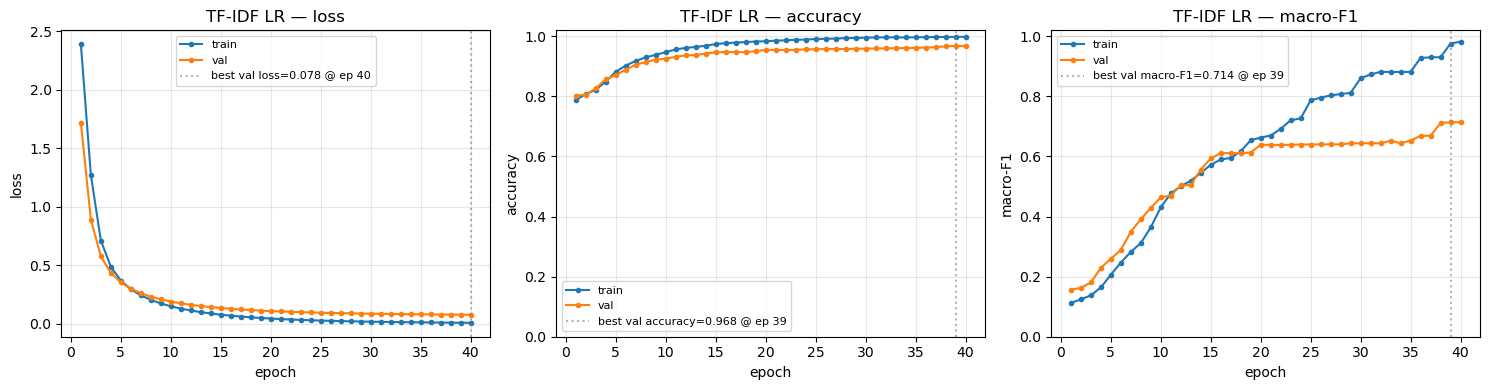


  TF-IDF LR — test diagnostics
accuracy     = 0.9216
macro-F1     = 0.5421
weighted-F1  = 0.9050

Per-class precision / recall / F1:
                   precision    recall  f1-score   support

     abbreviation      1.000     0.939     0.969        33
         aircraft      0.600     0.667     0.632         9
          airfare      0.898     0.917     0.907        48
   airfare+flight      0.000     0.000     0.000         1
          airline      0.972     0.921     0.946        38
          airport      1.000     0.500     0.667        18
         capacity      1.000     0.762     0.865        21
             city      0.000     0.000     0.000         6
         day_name      0.000     0.000     0.000         2
         distance      1.000     0.800     0.889        10
           flight      0.921     0.991     0.954       632
   flight+airfare      0.000     0.000     0.000        12
   flight+airline      0.000     0.000     0.000         1
        flight_no      1.000     0.625 

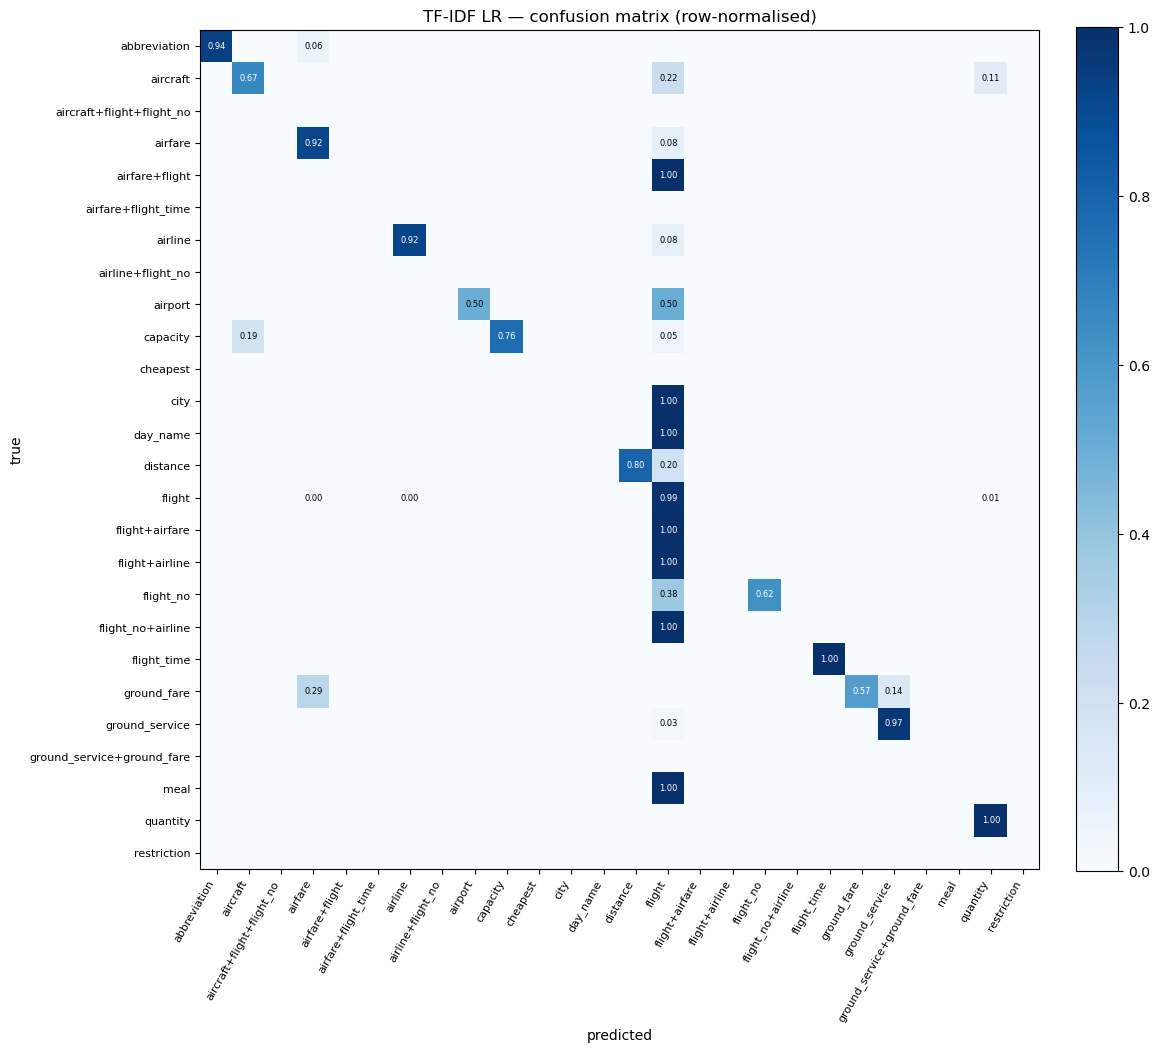


Top 10 confusions (count, true → pred):
    12  flight+airfare            → flight
     9  airport                   → flight
     6  meal                      → flight
     6  city                      → flight
     4  flight                    → quantity
     4  capacity                  → aircraft
     4  airfare                   → flight
     3  flight_no                 → flight
     3  airline                   → flight
     2  ground_fare               → airfare


In [59]:
# ── Loss helpers: CE vs focal + optional class weights ───────────────────────
def class_weights_from_labels(
    y: torch.Tensor, num_classes: int, mode: str | None = None
) -> torch.Tensor | None:
    """mode None = uniform; 'inv' or 'dampened_inv' = frequency-based weights."""
    if mode is None:
        return None
    if mode not in ("inv", "dampened_inv"):
        raise ValueError(f"Unknown CLASS_WEIGHT_MODE: {mode!r}")
    counts = torch.bincount(y, minlength=num_classes).float()
    mask = counts > 0
    K = mask.sum().float()
    N = float(len(y))
    ratio = N / (counts[mask] * K)
    cw = torch.zeros(num_classes)
    if mode == "inv":
        cw[mask] = ratio
    else:
        cw[mask] = ratio.sqrt()
    cw[mask] = cw[mask] / cw[mask].mean()
    return cw


class FocalLoss(nn.Module):
    """Multiclass focal loss on logits; optional per-class weight (same as CE)."""

    def __init__(self, gamma: float = 2.0, weight: torch.Tensor | None = None):
        super().__init__()
        self.gamma = gamma
        if weight is not None:
            self.register_buffer("class_weight", weight.clone())
        else:
            self.class_weight = None

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        log_pt = F.log_softmax(logits, dim=-1).gather(1, target.unsqueeze(1)).squeeze(1)
        pt = log_pt.exp()
        loss = -(1 - pt).pow(self.gamma) * log_pt
        if self.class_weight is not None:
            loss = loss * self.class_weight[target]
        return loss.mean()


def build_criterion(
    loss_type: str, class_weights: torch.Tensor | None, focal_gamma: float = 2.0
) -> nn.Module:
    if loss_type == "ce":
        return nn.CrossEntropyLoss(weight=class_weights)
    if loss_type == "focal":
        return FocalLoss(gamma=focal_gamma, weight=class_weights)
    raise ValueError(f"Unknown LOSS_TYPE: {loss_type!r} (use 'ce' or 'focal')")


# ── training-curve plot helper (shared by §3 LR + §4 TextCNN) ────────────────
def plot_history(history: list, name: str = "model"):
    """Plot train vs val curves for loss / acc / macro-F1 from a history list.

    Each history entry must be a dict with keys
        epoch, tr_loss, val_loss, tr_acc, val_acc, tr_macro_f1, val_macro_f1.
    """
    if not history:
        print(f"[plot_history] no history to plot for {name!r}.")
        return
    epochs = [h["epoch"] for h in history]
    tr_loss = [h["tr_loss"] for h in history]
    val_loss = [h["val_loss"] for h in history]
    tr_acc = [h["tr_acc"] for h in history]
    val_acc = [h["val_acc"] for h in history]
    tr_f1 = [h["tr_macro_f1"] for h in history]
    val_f1 = [h["val_macro_f1"] for h in history]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    # `lower_is_better` flips argmax→argmin so the "best epoch" line is correct for loss.
    panels = [
        ("loss", tr_loss, val_loss, None, True),
        ("accuracy", tr_acc, val_acc, (0.0, 1.02), False),
        ("macro-F1", tr_f1, val_f1, (0.0, 1.02), False),
    ]
    for ax, (metric, tr, val, ylim, lower_is_better) in zip(axes, panels):
        ax.plot(epochs, tr, label="train", marker="o", markersize=3, linewidth=1.5)
        ax.plot(epochs, val, label="val", marker="o", markersize=3, linewidth=1.5)
        best_idx = pd.Series(val).idxmin() if lower_is_better else pd.Series(val).idxmax()
        best_ep = int(epochs[int(best_idx)])
        best_val = val[int(best_idx)]
        ax.axvline(
            best_ep,
            color="grey",
            linestyle=":",
            alpha=0.6,
            label=f"best val {metric}={best_val:.3f} @ ep {best_ep}",
        )
        ax.set_xlabel("epoch")
        ax.set_ylabel(metric)
        ax.set_title(f"{name} — {metric}")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best", fontsize=8)
        if ylim is not None:
            ax.set_ylim(*ylim)
    fig.tight_layout()
    plt.show()


# ── per-model evaluation report (shared by §3 LR + §4 TextCNN) ───────────────
def evaluate_model(
    y_true,
    y_pred,
    label_names,
    name: str = "model",
    normalize: str | None = "true",
    top_confusions: int = 10,
):
    """Pretty-print test diagnostics: accuracy, per-class P/R/F1, confusion matrix.

    Parameters
    ----------
    y_true, y_pred : 1-D arrays of integer class IDs.
    label_names    : iterable of class names (e.g. label_encoder.classes_).
    normalize      : passed to sklearn.metrics.confusion_matrix; "true" =
                     row-normalised so each row sums to 1 (recall view), None
                     for raw counts.
    top_confusions : how many largest off-diagonal pairs to print.
    """
    label_names = list(label_names)
    n_classes = len(label_names)
    present = sorted(set(y_true) | set(y_pred))
    present_names = [label_names[i] for i in present]

    acc = accuracy_score(y_true, y_pred)
    mf1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    wf1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n{'=' * 72}")
    print(f"  {name} — test diagnostics")
    print(f"{'=' * 72}")
    print(f"accuracy     = {acc:.4f}")
    print(f"macro-F1     = {mf1:.4f}")
    print(f"weighted-F1  = {wf1:.4f}")

    print("\nPer-class precision / recall / F1:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=present,
            target_names=present_names,
            digits=3,
            zero_division=0,
        )
    )

    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    cm_disp = cm.astype(float)
    if normalize == "true":
        row_sums = cm_disp.sum(axis=1, keepdims=True)
        with np.errstate(invalid="ignore", divide="ignore"):
            cm_disp = np.where(row_sums > 0, cm_disp / row_sums, 0.0)

    fig, ax = plt.subplots(figsize=(max(8, n_classes * 0.45), max(7, n_classes * 0.42)))
    im = ax.imshow(
        cm_disp, cmap="Blues", vmin=0, vmax=1.0 if normalize == "true" else cm_disp.max() or 1
    )
    ax.set_xticks(range(n_classes))
    ax.set_yticks(range(n_classes))
    ax.set_xticklabels(label_names, rotation=60, ha="right", fontsize=8)
    ax.set_yticklabels(label_names, fontsize=8)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(
        f"{name} — confusion matrix" + (" (row-normalised)" if normalize == "true" else " (counts)")
    )
    fmt = "{:.2f}" if normalize == "true" else "{:.0f}"
    threshold = 0.5 if normalize == "true" else cm_disp.max() / 2.0
    for i in range(n_classes):
        for j in range(n_classes):
            if cm_disp[i, j] == 0:
                continue
            ax.text(
                j,
                i,
                fmt.format(cm_disp[i, j]),
                ha="center",
                va="center",
                fontsize=6,
                color="white" if cm_disp[i, j] > threshold else "black",
            )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()

    # ── top off-diagonal confusions (counts, not normalised) ────────────────
    cm_off = cm.copy()
    np.fill_diagonal(cm_off, 0)
    if cm_off.sum() > 0:
        flat = [
            (cm_off[i, j], i, j)
            for i in range(n_classes)
            for j in range(n_classes)
            if cm_off[i, j] > 0
        ]
        flat.sort(reverse=True)
        print(f"\nTop {min(top_confusions, len(flat))} confusions (count, true → pred):")
        for cnt, i, j in flat[:top_confusions]:
            print(f"  {cnt:>4d}  {label_names[i]:<25s} → {label_names[j]}")
    else:
        print("\nNo off-diagonal confusions — perfect classification on test split.")


# ── Choose loss + class weights ──────────────────────────────────────────────
# These are the defaults used by §3 (TF-IDF LR). §4 (TextCNN) reads them as a
# starting point but can override each one via TEXTCNN_LOSS_TYPE /
# TEXTCNN_CLASS_WEIGHT_MODE / TEXTCNN_FOCAL_GAMMA in the §4f config cell.
LOSS_TYPE = "focal"  # "ce" | "focal"
CLASS_WEIGHT_MODE = None  # None | "dampened_inv" | "inv"
FOCAL_GAMMA = 2.0

# ── 3a. TF-IDF vectoriser (feature extractor only) ───────────────────────────
# When `TFIDF_USE_MASKING` is True, the vectoriser uses `simple_tokenize`
# (defined in §1.5.5) which lowercases, collapses multi-word entities, and
# applies `MASK_ENTITIES`-driven placeholder substitution. When False, sklearn
# falls back to its default whitespace/word tokenisation on raw text.
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as _TFIDF_ENG_STOPS

TFIDF_USE_MASKING = True
TFIDF_MAX_FEATURES = 8_000
# Word n-grams: (1,1)=unigrams only ; (1,2)=uni+bigrams ; (2,2)=bigrams only ; etc.
TFIDF_NGRAM_RANGE = (1, 2)
print(f"[TF-IDF] ngram_range={TFIDF_NGRAM_RANGE}")

# Stop-word removal uses sklearn english list minus lowercase tokens kept here.
# (Edit the set for your task; duplicates with non-stops are harmless.)
TFIDF_REMOVE_STOPWORDS = False
TFIDF_STOPWORD_RESERVE = frozenset(
    {
        "from",
        "to",
        "on",
        "in",
        "at",
        "between",
        "and",
        "or",
        "via",
        "than",
        "my",
        "would",
        "like",
        "need",
        "show",
        "list",
        "give",
    }
)
if TFIDF_REMOVE_STOPWORDS:
    TFIDF_STOP_LIST = sorted(frozenset(_TFIDF_ENG_STOPS) - TFIDF_STOPWORD_RESERVE)
    _n_eng = len(_TFIDF_ENG_STOPS)
    print(
        "[TF-IDF] stop_words=ENGLISH_STOP_WORDS - TFIDF_STOPWORD_RESERVE  |  "
        f"removed={len(TFIDF_STOP_LIST)}/{_n_eng}  kept_from_reserve="
        f"{len(TFIDF_STOPWORD_RESERVE & frozenset(_TFIDF_ENG_STOPS))}"
    )
else:
    TFIDF_STOP_LIST = None
    print("[TF-IDF] stop_words=None (no sklearn stop-word list)")

if TFIDF_USE_MASKING:
    print(f"[TF-IDF] masking ON  (MASK_ENTITIES={sorted(MASK_ENTITIES) or 'empty'})")
    tfidf = TfidfVectorizer(
        analyzer="word",
        ngram_range=TFIDF_NGRAM_RANGE,
        max_features=TFIDF_MAX_FEATURES,
        sublinear_tf=True,
        strip_accents="unicode",
        tokenizer=simple_tokenize,  # already lowercases + collapses + masks
        lowercase=False,  # avoid double-lowercasing
        token_pattern=None,  # ignored when `tokenizer` is set
        stop_words=TFIDF_STOP_LIST,
    )
else:
    print("[TF-IDF] masking OFF (raw text)")
    tfidf = TfidfVectorizer(
        analyzer="word",
        ngram_range=TFIDF_NGRAM_RANGE,
        max_features=TFIDF_MAX_FEATURES,
        sublinear_tf=True,
        strip_accents="unicode",
        token_pattern=r"(?u)\b\w+\b",
        stop_words=TFIDF_STOP_LIST,
    )
tfidf.fit(train_df_tr["text"])


def tfidf_to_tensor(texts) -> torch.Tensor:
    X = tfidf.transform(texts)
    return torch.tensor(X.toarray(), dtype=torch.float32)


X_tr = tfidf_to_tensor(train_df_tr["text"])
X_val = tfidf_to_tensor(val_df["text"])
X_te = tfidf_to_tensor(test_df["text"])

y_tr = torch.tensor(train_df_tr["label"].values, dtype=torch.long)
y_val = torch.tensor(val_df["label"].values, dtype=torch.long)
y_te = torch.tensor(test_df["label"].values, dtype=torch.long)

print(f"TF-IDF feature dim: {X_tr.shape[1]}")


# ── 3b. PyTorch Logistic Regression ──────────────────────────────────────────
class LogisticRegression(nn.Module):
    """Single linear layer — multinomial logistic regression."""

    def __init__(self, in_features: int, num_classes: int):
        super().__init__()
        self.fc = nn.Linear(in_features, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc(x)  # raw logits, shape (B, C)


# ── 3c. Mini dataset / dataloader for dense tensors ──────────────────────────
class TensorDatasetShuffled(Dataset):
    def __init__(self, X: torch.Tensor, y: torch.Tensor):
        self.X, self.y = X, y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


def make_tensor_loader(X, y, shuffle=False):
    return DataLoader(TensorDatasetShuffled(X, y), batch_size=BATCH_SIZE, shuffle=shuffle)


# ── 3d. Training loop ─────────────────────────────────────────────────────────
def train_dense(
    model: nn.Module,
    tr_loader,
    val_loader,
    epochs=MAX_EPOCHS,
    patience=PATIENCE,
    lr=LR,
    class_weights=None,
    loss_type="ce",
    focal_gamma=2.0,
    criterion=None,
    name="model",
):
    model = model.to(DEVICE)
    if criterion is None:
        criterion = build_criterion(loss_type, class_weights, focal_gamma).to(DEVICE)
    else:
        criterion = criterion.to(DEVICE)
    optimiser = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimiser, mode="max", factor=0.5, patience=5)

    best_val_f1, best_state, no_improve = -1.0, None, 0
    history = []
    t0 = time.time()
    print(f"Loss type: {loss_type}, class weight: {class_weights}")

    for epoch in range(1, epochs + 1):
        model.train()
        tr_loss = 0.0
        tr_preds, tr_true = [], []
        for Xb, yb in tr_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimiser.zero_grad()
            logits = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimiser.step()
            tr_loss += loss.item() * len(yb)
            tr_preds.append(logits.detach().argmax(1).cpu())
            tr_true.append(yb.cpu())
        tr_loss /= len(tr_loader.dataset)
        tr_preds = torch.cat(tr_preds).numpy()
        tr_true = torch.cat(tr_true).numpy()
        tr_acc = accuracy_score(tr_true, tr_preds)
        tr_f1 = f1_score(tr_true, tr_preds, average="macro", zero_division=0)

        model.eval()
        val_loss = 0.0
        val_preds, val_true = [], []
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb_d, yb_d = Xb.to(DEVICE), yb.to(DEVICE)
                logits = model(Xb_d)
                val_loss += criterion(logits, yb_d).item() * len(yb)
                val_preds.append(logits.argmax(1).cpu())
                val_true.append(yb)
        val_loss /= len(val_loader.dataset)
        val_preds = torch.cat(val_preds).numpy()
        val_true = torch.cat(val_true).numpy()
        val_f1 = f1_score(val_true, val_preds, average="macro", zero_division=0)
        val_acc = accuracy_score(val_true, val_preds)

        scheduler.step(val_f1)
        history.append(
            {
                "epoch": epoch,
                "tr_loss": tr_loss,
                "val_loss": val_loss,
                "tr_acc": tr_acc,
                "val_acc": val_acc,
                "tr_macro_f1": tr_f1,
                "val_macro_f1": val_f1,
            }
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  early stop at epoch {epoch}")
                break

        if epoch % 5 == 0 or epoch == 1:
            print(
                f"  [{name}] ep {epoch:3d}  loss={tr_loss:.4f}  "
                f"val_acc={val_acc:.4f}  val_f1={val_f1:.4f}"
            )

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    elapsed = time.time() - t0

    # ── test evaluation ────────────────────────────────────────────────────────
    model.eval()
    te_preds = []
    with torch.no_grad():
        for Xb, _ in make_tensor_loader(X_te, y_te):
            te_preds.append(model(Xb.to(DEVICE)).argmax(1).cpu())
    te_preds = torch.cat(te_preds).numpy()
    te_true = y_te.numpy()

    te_acc = accuracy_score(te_true, te_preds)
    te_mf1 = f1_score(te_true, te_preds, average="macro", zero_division=0)
    te_wf1 = f1_score(te_true, te_preds, average="weighted", zero_division=0)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(
        f"\n  [{name}]  test_acc={te_acc:.4f}  "
        f"macro_f1={te_mf1:.4f}  weighted_f1={te_wf1:.4f}  "
        f"params={n_params:,}  time={elapsed:.1f}s"
    )
    return model, history, te_acc, te_mf1, te_wf1, n_params, te_preds


# ── 3e. Run ───────────────────────────────────────────────────────────────────
# After fit, TF-IDF columns = min(max_features, distinct terms); must match Linear in_features.
cw = class_weights_from_labels(y_tr, NUM_CLASSES, CLASS_WEIGHT_MODE)
cw = cw.to(DEVICE) if cw is not None else None

lr_model = LogisticRegression(X_tr.shape[1], NUM_CLASSES)
tr_loader_dense = make_tensor_loader(X_tr, y_tr, shuffle=True)
val_loader_dense = make_tensor_loader(X_val, y_val, shuffle=False)

lr_model, lr_hist, lr_acc, lr_mf1, lr_wf1, lr_params, lr_preds = train_dense(
    lr_model,
    tr_loader_dense,
    val_loader_dense,
    class_weights=cw,
    loss_type=LOSS_TYPE,
    focal_gamma=FOCAL_GAMMA,
    name="TF-IDF LR",
)

plot_history(lr_hist, name="TF-IDF LR")
evaluate_model(y_te.numpy(), lr_preds, label_encoder.classes_, name="TF-IDF LR")

## 4 — Modular CNN: Tokenizer × Embedding

A unified TextCNN where tokenization and embedding are **independent, swappable** components.

| Component | Options |
|-----------|---------|
| Tokenizer | `word` (regex) · `char` · `bpe` (SentencePiece) |
| Embedding | `learned` (random init) · `glove` (Stanford GloVe, local cache) |
| Filter sizes | any tuple, e.g. `(1,)`, `(2,3,4)`, `(1,2,3,4,5)` |

The CNN itself is Kim 2014 style with parallel 1-D convolutions + max-over-time pooling. Filter widths are configurable per experiment, including `k=1` (per-token unigram branch).

In [174]:
# ── 4a. Tokenizers (modular) ────────────────────────────────────────────────
# Allow letters / digits / underscore in a single token so collapsed multi-word
# entities like "838_am" or "2_o_clock_pm" survive intact.  Trailing class
# captures stray punctuation as its own token.
WORD_RE = re.compile(r"\[[a-z_]+\]|[a-zA-Z0-9_]+|[^\sa-zA-Z0-9_]")


class WordTokenizer:
    """Word-level tokenizer.

    Multi-word entity spans (e.g. "san francisco", "2 o'clock pm") are
    collapsed into single tokens ("san_francisco", "2_o_clock_pm"), and any
    bucket listed in `MASK_ENTITIES` (defined in section 1.5.5) is replaced
    with its placeholder (`[city]`, `[airline]`, `[date]`, `[time]`, `[num]`,
    ...). BPE/Char tokenizers ignore both.

    Pass `mask=False` at construction time to opt out of the placeholder
    substitution (controlled per-pipeline via `TEXTCNN_USE_MASKING`); multi-
    word collapse always runs because it's needed to look up entities.
    """

    def __init__(self, mask: bool = True):
        self.mask = mask

    def tokenize(self, text: str) -> list[str]:
        text = _collapse_multiword(text.lower())
        toks = WORD_RE.findall(text)
        return [_mask_token(t) for t in toks] if (self.mask and MASK_ENTITIES) else toks


class CharTokenizer:
    def tokenize(self, text: str) -> list[str]:
        return list(text.lower())


class SentencePieceTokenizer:
    """BPE tokenizer via SentencePiece. Trains/loads a model file.

    Honors the same masking config as the word pipeline (section 1.5.5):

    * Multi-word entity spans (e.g. "san francisco") are collapsed to single
      tokens ("san_francisco") before BPE so they're not split mid-phrase.
    * If `MASK_ENTITIES` is non-empty, recognized entity tokens are replaced
      with their placeholders (`[city]`, `[airline]`, `[date]`, `[time]`,
      `[num]`, ...) before BPE.
    * The placeholder strings are added to BPE training as
      `user_defined_symbols`, so they stay atomic in the vocab and are never
      sub-split into "[", "c", "it", "y", "]" pieces.

    NOTE: When `MASK_ENTITIES` or the `mask` flag changes, delete the cached
    `.spm/*.model` file (or use a different `model_path`) so the model is
    retrained with merges that reflect the new masking.  The §4f config cell
    encodes the flag in the cache filename for you (`atis_bpe_masked.model`
    vs `atis_bpe_raw.model`).
    """

    def __init__(self, model_path: Path, mask: bool = True):
        self.model_path = Path(model_path)
        self.mask = mask
        self._sp = None

    def _preprocess(self, text: str) -> str:
        text = _collapse_multiword(text.lower())
        if self.mask and MASK_ENTITIES:
            text = " ".join(_mask_token(t) for t in WORD_RE.findall(text))
        return text

    def train(
        self, corpus: list[str], vocab_size: int = 4000, model_type: str = "bpe"
    ) -> "SentencePieceTokenizer":
        self.model_path.parent.mkdir(parents=True, exist_ok=True)
        processed = [self._preprocess(s) for s in corpus]
        corpus_file = self.model_path.with_suffix(".txt")
        corpus_file.write_text("\n".join(processed), encoding="utf-8")
        spm.SentencePieceTrainer.Train(
            input=str(corpus_file),
            model_prefix=str(self.model_path.with_suffix("")),
            vocab_size=vocab_size,
            model_type=model_type,
            character_coverage=1.0,
            pad_id=0,
            unk_id=1,
            bos_id=-1,
            eos_id=-1,
            user_defined_symbols=list(_MASK_TOKEN.values()),
            # Heavy masking shrinks the BPE alphabet (most words become a few
            # placeholder tokens), so BPE may not be able to reach `vocab_size`
            # via merges alone. `hard_vocab_limit=False` lets training stop at
            # a smaller vocab instead of crashing.
            hard_vocab_limit=False,
        )
        return self.load()

    def load(self) -> "SentencePieceTokenizer":
        self._sp = spm.SentencePieceProcessor(model_file=str(self.model_path))
        return self

    def tokenize(self, text: str) -> list[str]:
        if self._sp is None:
            self.load()
        return self._sp.encode(self._preprocess(text), out_type=str)


# ── 4b. Vocabulary ───────────────────────────────────────────────────────────
class Vocabulary:
    PAD, UNK = "<pad>", "<unk>"

    def __init__(self, min_freq: int = 1):
        self.min_freq = min_freq
        self._tok2id: dict[str, int] = {}
        self._id2tok: list[str] = []

    def build(self, corpus: list[list[str]]) -> "Vocabulary":
        from collections import Counter

        freq = Counter(t for sent in corpus for t in sent)
        self._tok2id = {self.PAD: 0, self.UNK: 1}
        self._id2tok = [self.PAD, self.UNK]
        for tok, cnt in freq.most_common():
            if cnt >= self.min_freq and tok not in self._tok2id:
                self._tok2id[tok] = len(self._id2tok)
                self._id2tok.append(tok)
        return self

    def encode(self, tokens: list[str]) -> list[int]:
        unk = self._tok2id[self.UNK]
        return [self._tok2id.get(t, unk) for t in tokens]

    @property
    def pad_id(self) -> int:
        return self._tok2id[self.PAD]

    @property
    def itos(self) -> list[str]:
        return self._id2tok

    @property
    def stoi(self) -> dict[str, int]:
        return self._tok2id

    def __len__(self) -> int:
        return len(self._id2tok)

In [175]:
# ── 4c. Embedding factory ────────────────────────────────────────────────────
def build_embedding(
    vocab: Vocabulary,
    kind: str,
    embed_dim: int = EMBED_DIM,
    glove_name: str = "6B",
    glove_dim: int = 100,
    freeze: bool = False,
) -> nn.Embedding:
    """kind='learned' (random init) or 'glove' (GloVe zip download + lookup)."""
    if kind == "learned":
        return nn.Embedding(len(vocab), embed_dim, padding_idx=vocab.pad_id)
    if kind == "glove":
        glove = load_glove_vectors(glove_name, glove_dim, cache=ROOT / ".vector_cache")
        weight = torch.empty(len(vocab), glove_dim)
        nn.init.normal_(weight, mean=0.0, std=0.1)
        weight[vocab.pad_id].zero_()
        n_hits = 0
        for tok, idx in vocab.stoi.items():
            if tok in glove.stoi:
                weight[idx] = glove.vectors[glove.stoi[tok]]
                n_hits += 1
        print(f"  GloVe coverage: {n_hits}/{len(vocab)} tokens ({n_hits / len(vocab):.1%})")
        return nn.Embedding.from_pretrained(weight, freeze=freeze, padding_idx=vocab.pad_id)
    raise ValueError(f"Unknown embedding kind: {kind!r} (use 'learned' or 'glove')")

In [ ]:
# ── 4d. Unified TextCNN ──────────────────────────────────────────────────────
class TextCNN(nn.Module):
    """Kim 2014 CNN with configurable filter widths."""

    def __init__(
        self,
        embedding: nn.Embedding,
        num_classes: int,
        filter_sizes=(2, 3, 4),
        num_filters: int = 128,
        dropout: float = 0.5,
    ):
        super().__init__()
        self.embedding = embedding
        embed_dim = embedding.embedding_dim
        self.filter_sizes = tuple(filter_sizes)
        self.convs = nn.ModuleList(
            [nn.Conv1d(embed_dim, num_filters, k) for k in self.filter_sizes]
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(self.filter_sizes), num_classes)

        nn.init.xavier_uniform_(self.fc.weight)
        for conv in self.convs:
            nn.init.kaiming_uniform_(conv.weight, nonlinearity="relu")

    def forward(self, ids: torch.Tensor, lengths: torch.Tensor = None) -> torch.Tensor:
        x = self.embedding(ids).transpose(1, 2)  # (B, E, L)
        pooled = [F.relu(conv(x)).max(dim=2).values for conv in self.convs]
        out = torch.cat(pooled, dim=1)  # (B, num_filters * K)
        return self.fc(self.dropout(out))

In [177]:
# ── 4e. Sequence loaders + train loop ────────────────────────────────────────
class SeqDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        tokenize_fn: Callable[[str], list[str]],
        vocab: Vocabulary,
        max_len: int,
    ):
        self.texts = df["text"].tolist()
        self.labels = df["label"].tolist()
        self.tokenize = tokenize_fn
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        toks = self.tokenize(self.texts[i])[: self.max_len]
        ids = self.vocab.encode(toks) or [self.vocab.pad_id]
        return torch.tensor(ids, dtype=torch.long), len(ids), self.labels[i]


def collate_pad(batch, pad_id: int, min_len: int = 1):
    """Pad to max(batch length, min_len) so Conv1d never sees a too-short batch."""
    seqs, lengths, labels = zip(*batch)
    max_l = max(max(lengths), min_len)
    padded = torch.full((len(seqs), max_l), pad_id, dtype=torch.long)
    for i, s in enumerate(seqs):
        padded[i, : lengths[i]] = s
    return (padded, torch.tensor(lengths, dtype=torch.long), torch.tensor(labels, dtype=torch.long))


def make_seq_loader(df, tokenize_fn, vocab, max_len, min_len: int = 1, shuffle=False):
    ds = SeqDataset(df, tokenize_fn, vocab, max_len)
    return DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        collate_fn=lambda b: collate_pad(b, vocab.pad_id, min_len),
    )


def train_seq(
    model: nn.Module,
    name: str,
    tr_loader,
    val_loader,
    test_loader,
    epochs=MAX_EPOCHS,
    patience=PATIENCE,
    lr=LR,
    class_weights=None,
    loss_type="ce",
    focal_gamma=2.0,
    criterion=None,
):
    model = model.to(DEVICE)
    if criterion is None:
        criterion = build_criterion(loss_type, class_weights, focal_gamma).to(DEVICE)
    else:
        criterion = criterion.to(DEVICE)
    optimiser = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimiser, mode="max", factor=0.5, patience=2)

    best_val_f1, best_state, no_improve = -1.0, None, 0
    history = []
    t0 = time.time()
    # print(f"Loss type: {loss_type}, class weight: {class_weights}")

    for epoch in range(1, epochs + 1):
        model.train()
        tr_loss = 0.0
        tr_preds, tr_true = [], []
        for ids, lengths, labels in tr_loader:
            ids, lengths, labels = ids.to(DEVICE), lengths.to(DEVICE), labels.to(DEVICE)
            optimiser.zero_grad()
            logits = model(ids, lengths)
            loss = criterion(logits, labels)
            loss.backward()
            optimiser.step()
            tr_loss += loss.item() * len(labels)
            tr_preds.append(logits.detach().argmax(1).cpu())
            tr_true.append(labels.cpu())
        tr_loss /= len(tr_loader.dataset)
        tr_preds = torch.cat(tr_preds).numpy()
        tr_true = torch.cat(tr_true).numpy()
        tr_acc = accuracy_score(tr_true, tr_preds)
        tr_f1 = f1_score(tr_true, tr_preds, average="macro", zero_division=0)

        model.eval()
        val_loss = 0.0
        val_preds, val_true = [], []
        with torch.no_grad():
            for ids, lengths, labels in val_loader:
                ids_d, lens_d, labels_d = ids.to(DEVICE), lengths.to(DEVICE), labels.to(DEVICE)
                logits = model(ids_d, lens_d)
                val_loss += criterion(logits, labels_d).item() * len(labels)
                val_preds.append(logits.argmax(1).cpu())
                val_true.append(labels)
        val_loss /= len(val_loader.dataset)
        val_preds = torch.cat(val_preds).numpy()
        val_true = torch.cat(val_true).numpy()
        val_f1 = f1_score(val_true, val_preds, average="macro", zero_division=0)
        val_acc = accuracy_score(val_true, val_preds)

        scheduler.step(val_f1)
        history.append(
            {
                "epoch": epoch,
                "tr_loss": tr_loss,
                "val_loss": val_loss,
                "tr_acc": tr_acc,
                "val_acc": val_acc,
                "tr_macro_f1": tr_f1,
                "val_macro_f1": val_f1,
            }
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  early stop at epoch {epoch}")
                break

        if epoch % 5 == 0 or epoch == 1:
            print(
                f"  [{name}] ep {epoch:3d}  loss={tr_loss:.4f}  "
                f"val_acc={val_acc:.4f}  val_f1={val_f1:.4f}"
            )

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    elapsed = time.time() - t0

    model.eval()
    te_preds, te_true_acc = [], []
    with torch.no_grad():
        for ids, lengths, labels in test_loader:
            te_preds.append(model(ids.to(DEVICE), lengths.to(DEVICE)).argmax(1).cpu())
            te_true_acc.append(labels)
    te_preds = torch.cat(te_preds).numpy()
    te_true = torch.cat(te_true_acc).numpy()

    te_acc = accuracy_score(te_true, te_preds)
    te_mf1 = f1_score(te_true, te_preds, average="macro", zero_division=0)
    te_wf1 = f1_score(te_true, te_preds, average="weighted", zero_division=0)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(
        f"\n  [{name}]  test_acc={te_acc:.4f}  "
        f"macro_f1={te_mf1:.4f}  weighted_f1={te_wf1:.4f}  "
        f"params={n_params:,}  time={elapsed:.1f}s"
    )
    return model, history, te_acc, te_mf1, te_wf1, n_params, te_preds

[TextCNN] tokenizer=word  masking=OFF  (MASK_ENTITIES=['airline', 'airport-code', 'airport-name', 'city', 'date', 'numeric', 'state', 'time'])
Tokenizer=word  vocab=936  filter_sizes=(2, 3, 4, 5)  num_filters=128  max_len=50
  GloVe coverage: 748/936 tokens (79.9%)
[TextCNN] loss=focal  focal_gamma=2.0  class_weight_mode='dampened_inv'
  [CNN [word+glove k=2_3_4_5]] ep   1  loss=0.2087  val_acc=0.9307  val_f1=0.5487
  [CNN [word+glove k=2_3_4_5]] ep   5  loss=0.0138  val_acc=0.9548  val_f1=0.7006
  [CNN [word+glove k=2_3_4_5]] ep  10  loss=0.0043  val_acc=0.9719  val_f1=0.7439
  [CNN [word+glove k=2_3_4_5]] ep  15  loss=0.0027  val_acc=0.9779  val_f1=0.8595
  [CNN [word+glove k=2_3_4_5]] ep  20  loss=0.0012  val_acc=0.9759  val_f1=0.7914
  early stop at epoch 25

  [CNN [word+glove k=2_3_4_5]]  test_acc=0.9418  macro_f1=0.5841  weighted_f1=0.9356  params=286,650  time=43.9s


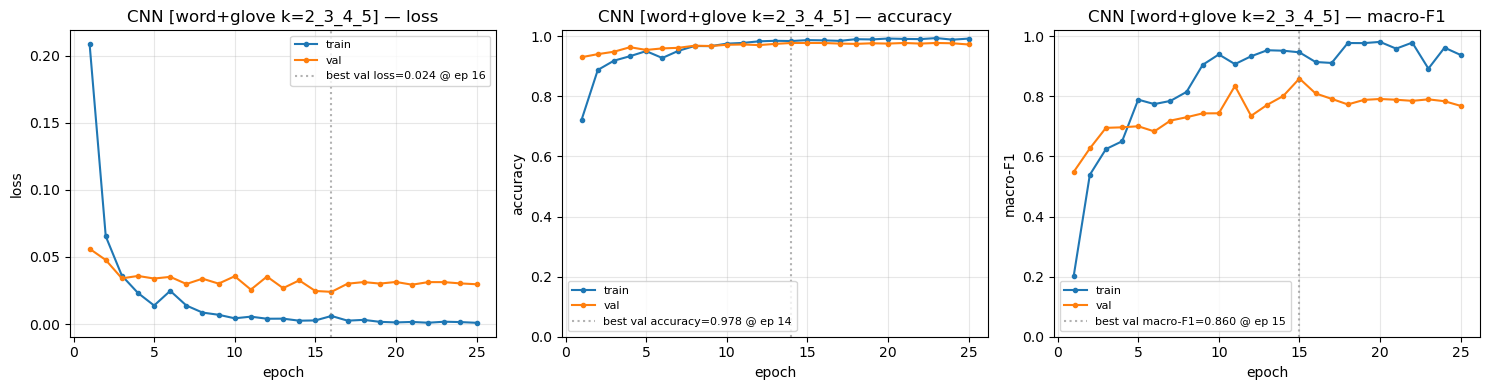


  CNN [word+glove k=2_3_4_5] — test diagnostics
accuracy     = 0.9418
macro-F1     = 0.5841
weighted-F1  = 0.9356

Per-class precision / recall / F1:
                   precision    recall  f1-score   support

     abbreviation      1.000     0.848     0.918        33
         aircraft      0.533     0.889     0.667         9
          airfare      0.906     1.000     0.950        48
   airfare+flight      0.000     0.000     0.000         1
          airline      0.927     1.000     0.962        38
          airport      1.000     0.778     0.875        18
         capacity      0.810     0.810     0.810        21
             city      0.000     0.000     0.000         6
         day_name      0.000     0.000     0.000         2
         distance      1.000     0.900     0.947        10
           flight      0.969     0.981     0.975       632
   flight+airfare      0.833     0.417     0.556        12
   flight+airline      0.000     0.000     0.000         1
        flight_no     

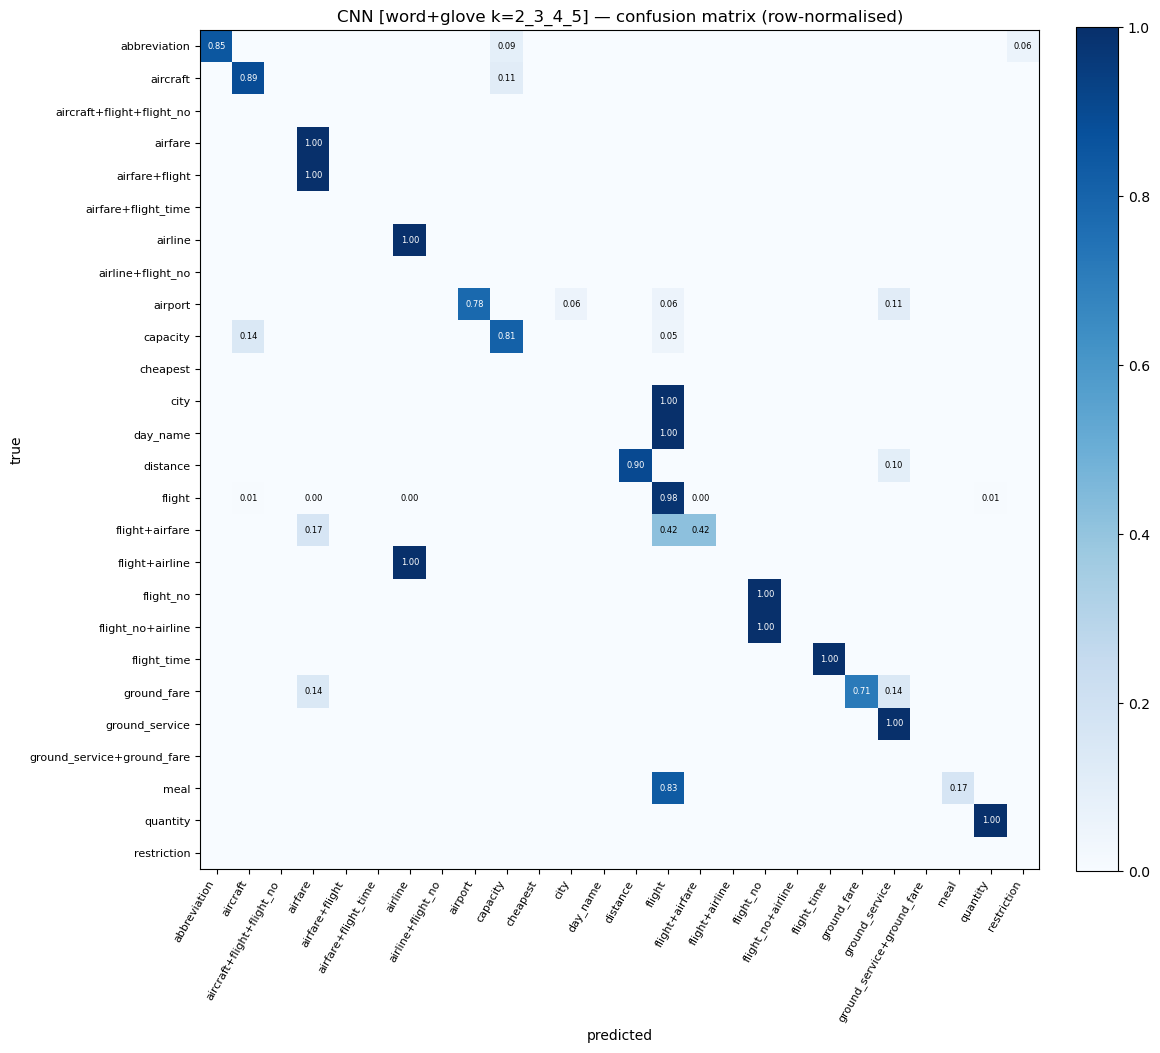


Top 10 confusions (count, true → pred):
     6  city                      → flight
     5  meal                      → flight
     5  flight+airfare            → flight
     4  flight                    → quantity
     4  flight                    → aircraft
     3  capacity                  → aircraft
     3  abbreviation              → capacity
     2  flight+airfare            → airfare
     2  flight                    → airline
     2  day_name                  → flight


In [178]:
# ── 4f. Config + run ─────────────────────────────────────────────────────────
TOKENIZER_TYPE = "word"  # "word" | "char" | "bpe"
TEXTCNN_USE_MASKING = False  # honor MASK_ENTITIES (cell §1.5.5) for word/BPE; char ignores it
EMBEDDING_TYPE = "glove"  # "learned" | "glove"
BPE_VOCAB_SIZE = 3000
GLOVE_NAME, GLOVE_DIM = "6B", 100
FREEZE_PRETRAINED = False
FILTER_SIZES = None  # None = per-tokenizer default (else tuple, e.g. (1,), (2,3,4))
NUM_FILTERS = None  # None = per-tokenizer default

# ── loss / class-weight overrides (default to §3 globals) ────────────────────
TEXTCNN_LOSS_TYPE = "focal"  # "ce" | "focal"
TEXTCNN_FOCAL_GAMMA = FOCAL_GAMMA  # only used when TEXTCNN_LOSS_TYPE == "focal"
TEXTCNN_CLASS_WEIGHT_MODE = "dampened_inv"  # None | "inv" | "dampened_inv"


def _per_tokenizer_defaults(tok_type: str):
    if tok_type == "char":
        return {"filter_sizes": (3, 5, 7), "num_filters": 256, "max_len": 200}
    return {"filter_sizes": (2, 3, 4, 5), "num_filters": 128, "max_len": 50}


_d = _per_tokenizer_defaults(TOKENIZER_TYPE)
filter_sizes = tuple(FILTER_SIZES) if FILTER_SIZES is not None else _d["filter_sizes"]
num_filters = NUM_FILTERS if NUM_FILTERS is not None else _d["num_filters"]
max_len = _d["max_len"]

# ── tokenizer ────────────────────────────────────────────────────────────────
print(
    f"[TextCNN] tokenizer={TOKENIZER_TYPE}  "
    f"masking={'ON' if TEXTCNN_USE_MASKING else 'OFF'}  "
    f"(MASK_ENTITIES={sorted(MASK_ENTITIES) or 'empty'})"
)

if TOKENIZER_TYPE == "word":
    tokenizer = WordTokenizer(mask=TEXTCNN_USE_MASKING)
elif TOKENIZER_TYPE == "char":
    tokenizer = CharTokenizer()  # char tokenizer ignores entity-level masking
elif TOKENIZER_TYPE == "bpe":
    # Cache BPE under different filenames so flipping the flag auto-retrains
    # without manual `.spm/` cleanup.
    spm_name = "atis_bpe_masked.model" if TEXTCNN_USE_MASKING else "atis_bpe_raw.model"
    spm_path = ROOT / "notebooks" / ".spm" / spm_name
    tokenizer = SentencePieceTokenizer(spm_path, mask=TEXTCNN_USE_MASKING)
    if not spm_path.exists():
        print(f"Training BPE → {spm_name} (vocab_size={BPE_VOCAB_SIZE})…")
        tokenizer.train(train_df_tr["text"].tolist(), vocab_size=BPE_VOCAB_SIZE)
    else:
        tokenizer.load()
else:
    raise ValueError(f"Unknown TOKENIZER_TYPE: {TOKENIZER_TYPE!r}")

# ── vocab ────────────────────────────────────────────────────────────────────
train_tokens = [tokenizer.tokenize(t) for t in train_df_tr["text"]]
vocab = Vocabulary(min_freq=1).build(train_tokens)
print(
    f"Tokenizer={TOKENIZER_TYPE}  vocab={len(vocab):,}  "
    f"filter_sizes={filter_sizes}  num_filters={num_filters}  max_len={max_len}"
)

# ── embedding (GloVe overrides EMBED_DIM with GLOVE_DIM) ─────────────────────
embed_dim = GLOVE_DIM if EMBEDDING_TYPE == "glove" else EMBED_DIM
embedding = build_embedding(
    vocab,
    EMBEDDING_TYPE,
    embed_dim=embed_dim,
    glove_name=GLOVE_NAME,
    glove_dim=GLOVE_DIM,
    freeze=FREEZE_PRETRAINED,
)

# ── loaders (min_len ensures Conv1d sees enough tokens for max kernel) ──────
min_len = max(filter_sizes)
tr_seq = make_seq_loader(train_df_tr, tokenizer.tokenize, vocab, max_len, min_len, shuffle=True)
val_seq = make_seq_loader(val_df, tokenizer.tokenize, vocab, max_len, min_len)
te_seq = make_seq_loader(test_df, tokenizer.tokenize, vocab, max_len, min_len)

# ── per-CNN class weights (uses TEXTCNN_CLASS_WEIGHT_MODE, not the §3 one) ──
y_tr_cnn = torch.tensor(train_df_tr["label"].values, dtype=torch.long)
cw_cnn = class_weights_from_labels(y_tr_cnn, NUM_CLASSES, TEXTCNN_CLASS_WEIGHT_MODE)
cw_cnn = cw_cnn.to(DEVICE) if cw_cnn is not None else None
print(
    f"[TextCNN] loss={TEXTCNN_LOSS_TYPE}  "
    f"focal_gamma={TEXTCNN_FOCAL_GAMMA if TEXTCNN_LOSS_TYPE == 'focal' else 'n/a'}  "
    f"class_weight_mode={TEXTCNN_CLASS_WEIGHT_MODE!r}"
)

# ── model + run ──────────────────────────────────────────────────────────────
cnn = TextCNN(
    embedding, NUM_CLASSES, filter_sizes=filter_sizes, num_filters=num_filters, dropout=0.5
)

run_name = f"CNN [{TOKENIZER_TYPE}+{EMBEDDING_TYPE} k={'_'.join(map(str, filter_sizes))}]"
cnn_model, cnn_hist, cnn_acc, cnn_mf1, cnn_wf1, cnn_params, cnn_preds = train_seq(
    cnn,
    run_name,
    tr_seq,
    val_seq,
    te_seq,
    class_weights=cw_cnn,
    loss_type=TEXTCNN_LOSS_TYPE,
    focal_gamma=TEXTCNN_FOCAL_GAMMA,
)

plot_history(cnn_hist, name=run_name)
evaluate_model(test_df["label"].values, cnn_preds, label_encoder.classes_, name=run_name)

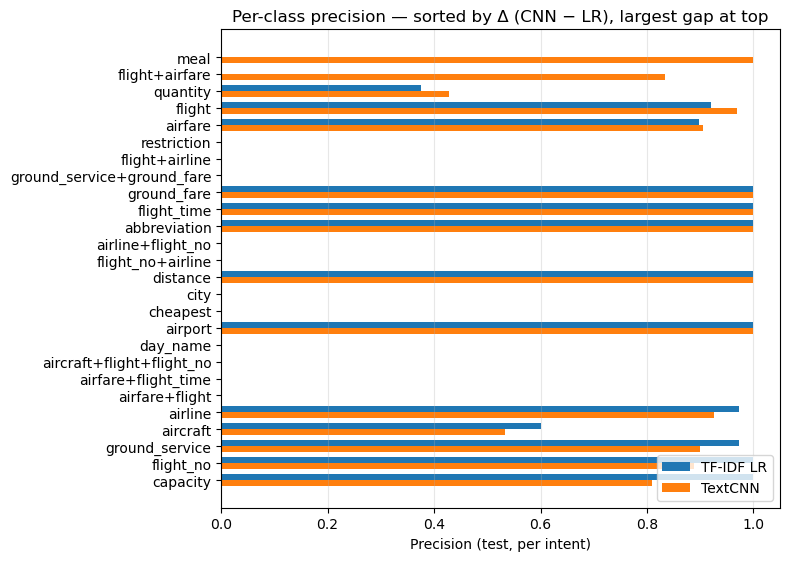

Per-class precision (full table, same sort as plot):
                    intent  precision_lr  precision_cnn  cnn_minus_lr
                      meal        0.0000         1.0000        1.0000
            flight+airfare        0.0000         0.8333        0.8333
                  quantity        0.3750         0.4286        0.0536
                    flight        0.9206         0.9688        0.0482
                   airfare        0.8980         0.9057        0.0077
               restriction        0.0000         0.0000        0.0000
            flight+airline        0.0000         0.0000        0.0000
ground_service+ground_fare        0.0000         0.0000        0.0000
               ground_fare        1.0000         1.0000        0.0000
               flight_time        1.0000         1.0000        0.0000
              abbreviation        1.0000         1.0000        0.0000
         airline+flight_no        0.0000         0.0000        0.0000
         flight_no+airline        0.0

,text,intent,pred_lr,pred_cnn
1,on april first i need a ticket from tacoma to san jose departing before 7 am,airfare,flight,airfare
154,what airlines off from love field between 6 and 10 am on june sixth,airline,flight,airline
206,list all flights and their fares from indianapolis to memphis on a monday morning,flight+airfare,flight,flight+airfare
207,list all flights and their fares from memphis to miami on a wednesday evening,flight+airfare,flight,flight+airfare
208,list all flights and their fares for all flights between miami and indianapolis,flight+airfare,flight,flight+airfare
232,list the distance in miles from new york 's la guardia airport to downtown new york city,distance,flight,distance
235,list limousine rates for the city of boston,ground_fare,airfare,ground_fare
292,i would like to have the airline that flies toronto detroit and st. louis,airline,flight,airline
305,show me the cheapest first class round trip from new york to miami,flight,airfare,flight
315,and now show me ground transportation that i could get in boston late night,ground_service,flight,ground_service



=== CNN wrong only (LR correct): 12 rows ===
Top true intents:
intent
flight          7
abbreviation    3
airport         1
capacity        1


,text,intent,pred_lr,pred_cnn
114,show me the connecting flights between boston and denver and the types of aircraft used,flight,flight,aircraft
168,which airport is closest to ontario california,airport,airport,flight
372,what is the seating capacity for the aircraft m80,capacity,capacity,aircraft
373,are there any flights between dallas and phoenix using a dc10 aircraft,flight,flight,aircraft
416,i want to fly from nashville to seattle and i want the cheapest fare round trip,flight,flight,airfare
538,what are restrictions ap 57,abbreviation,abbreviation,restriction
596,what does the restriction ap58 mean,abbreviation,abbreviation,restriction
655,list delta flights from seattle to salt lake city with aircraft type,flight,flight,aircraft
663,give me the flights and fares for a trip to cleveland from miami on wednesday,flight,flight,flight+airfare
770,what is 73s,abbreviation,abbreviation,capacity



=== Both wrong: 40 rows ===
Top true intents:
intent
flight+airfare    7
city              6
meal              5
flight            5
airport           3
capacity          3
day_name          2
ground_fare       2
abbreviation      2
aircraft          1
airfare+flight    1
flight+airline    1


,text,intent,pred_lr,pred_cnn
12,show flight and prices kansas city to chicago on next wednesday arriving in chicago by 7 pm,flight+airfare,flight,flight
34,what day of the week do flights from nashville to tacoma fly on,day_name,flight,flight
36,what days of the week do flights from san jose to nashville fly on,day_name,flight,flight
50,what meals are served on american flight 811 from tampa to milwaukee,meal,flight,flight
51,what meals are served on american flight 665 673 from milwaukee to seattle,meal,flight,flight
93,i would like to know what airports are in los angeles,airport,flight,ground_service
108,to what cities from boston does america west fly first class,city,flight,flight
137,what 's the fare for a taxi to denver,ground_fare,airfare,airfare
138,what are the fares for ground transportation in denver,ground_fare,ground_service,ground_service
176,what meals are available on dl 468 which al arrives in san francisco at 950 am,meal,flight,flight


In [180]:
from sklearn.metrics import precision_recall_fscore_support

try:
    from IPython.display import display
except ImportError:
    display = print

INSPECT_ROWS = 25

y_te_vec = np.asarray(test_df["label"].values, dtype=np.int64)
lr_p = np.asarray(lr_preds).reshape(-1).astype(np.int64)
cnn_p = np.asarray(cnn_preds).reshape(-1).astype(np.int64)
n_te = len(test_df)
assert lr_p.shape == cnn_p.shape == y_te_vec.shape == (n_te,), (
    lr_p.shape,
    cnn_p.shape,
    y_te_vec.shape,
    n_te,
)

lab = np.arange(NUM_CLASSES)
p_lr, _, _, _ = precision_recall_fscore_support(
    y_te_vec, lr_p, labels=lab, average=None, zero_division=0
)
p_cnn, _, _, _ = precision_recall_fscore_support(
    y_te_vec, cnn_p, labels=lab, average=None, zero_division=0
)

classes = np.asarray(label_encoder.classes_)
delta = p_cnn - p_lr
order = np.argsort(delta)[::-1]
p_lr_o, p_cnn_o = p_lr[order], p_cnn[order]
intent_o = classes[order]
y_rng = np.arange(NUM_CLASSES)
h = 0.35
fig_h = max(5.5, NUM_CLASSES * 0.22)
_, ax_prec = plt.subplots(figsize=(8, fig_h))
ax_prec.barh(y_rng - h / 2, p_lr_o, h, label="TF-IDF LR")
ax_prec.barh(y_rng + h / 2, p_cnn_o, h, label="TextCNN")
ax_prec.set_yticks(y_rng)
ax_prec.set_yticklabels(intent_o)
ax_prec.set_xlim(0, 1.05)
ax_prec.invert_yaxis()
ax_prec.set_xlabel("Precision (test, per intent)")
ax_prec.set_title("Per-class precision — sorted by Δ (CNN − LR), largest gap at top")
ax_prec.legend(loc="lower right")
ax_prec.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

prec_tbl = pd.DataFrame(
    {
        "intent": intent_o,
        "precision_lr": p_lr_o,
        "precision_cnn": p_cnn_o,
        "cnn_minus_lr": p_cnn_o - p_lr_o,
    }
)
print("Per-class precision (full table, same sort as plot):")
print(prec_tbl.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

m_lr_only_wrong = (lr_p != y_te_vec) & (cnn_p == y_te_vec)
m_cnn_only_wrong = (lr_p == y_te_vec) & (cnn_p != y_te_vec)
m_both_wrong = (lr_p != y_te_vec) & (cnn_p != y_te_vec)


def _error_slice(mask: np.ndarray) -> pd.DataFrame:
    out = test_df.loc[mask].copy()
    out["pred_lr"] = label_encoder.inverse_transform(lr_p[mask])
    out["pred_cnn"] = label_encoder.inverse_transform(cnn_p[mask])
    return out


cols = ["text", "intent", "pred_lr", "pred_cnn"]
df_lr_only_wrong = _error_slice(m_lr_only_wrong)
df_cnn_only_wrong = _error_slice(m_cnn_only_wrong)
df_both_wrong = _error_slice(m_both_wrong)

print(f"\n=== LR wrong only (CNN correct): {len(df_lr_only_wrong)} rows ===")
if len(df_lr_only_wrong):
    print("Top true intents:")
    print(df_lr_only_wrong["intent"].value_counts().head(12).to_string())
    display(df_lr_only_wrong[cols].head(INSPECT_ROWS))

print(f"\n=== CNN wrong only (LR correct): {len(df_cnn_only_wrong)} rows ===")
if len(df_cnn_only_wrong):
    print("Top true intents:")
    print(df_cnn_only_wrong["intent"].value_counts().head(12).to_string())
    display(df_cnn_only_wrong[cols].head(INSPECT_ROWS))

print(f"\n=== Both wrong: {len(df_both_wrong)} rows ===")
if len(df_both_wrong):
    print("Top true intents:")
    print(df_both_wrong["intent"].value_counts().head(12).to_string())
    display(df_both_wrong[cols].head(INSPECT_ROWS))